In [1]:
import pandas as pd # For data manipulation
import numpy as np # For numerical operations
import glob # to read all the files at once
import os # Get the current working directory
import re # Regular expressions
import matplotlib.pyplot as plt # For plotting
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns # For plotting
import pingouin as pg
from scipy.optimize import minimize
import pickle
from itertools import combinations
from sklearn.decomposition import PCA

Data description:

- Phase (1 = training phase, 2 = test phase)

- Block  (1-3 for training phase, 1 only for test phase)

- Trial sequence # within block (1-60 for training blocks, 1-300 for test block)

- Total Trial number in experiment (1-480)

- Item #  (1-480)

- Oldnew (1 for study item, 0 novel transfer item)

- Subtype #  (1-30)

- Category # (1=Ig, 2=Met, 3 = Sed.)

- Category response (1=Ig, 2=Met, 3 = Sed.)

- Correct (1=correct, 0=incorrect)

- Rt in milliseconds

Experimental Design:

**Study Phase**

20 unique objects from each category (igneous, metamorphic, sadimentary) in each condition. **Total** - 20 objects * 3 categories = 60 objects. Each was repeated 3 times => 180 study trials.

- In `High` condition: 10 unique sub-categories (e.g. granite, basalt) from each category 

- In `Low` condition: 5, 9, 9 unique sub-categories from categories 1, 2, 3, respectively


**Test Phase**

10 unique sub-categories from each category in both conditions. The exact objects varied across subjects and conditions

The number of categories also varied but was approximately equal (~100)

**On average**, there were 38 study objects and 262 novel objects in the test phase

In [46]:
# Load saved data
with open('GCM_results.pkl', 'rb') as f:
    saved = pickle.load(f)

models_fits     = saved['models_fits']
all_predictions = saved['all_predictions']
image_info      = saved['image_info']
distances_dict  = saved['distances_dict']

print('Loaded successfully')
print(f"Models: {list(models_fits.keys())}")

Loaded successfully
Models: ['GCM_c', 'GCM_c_per_cond', 'GCM_ck', 'GCM_ck_per_cond', 'GCM_cwb', 'GCM_cwb_per_cond', 'GCM_cwb_k', 'GCM_cwb_k_per_cond']


# Load data

In [2]:
# Get all JSON files in the folder
files = glob.glob(os.path.join("Data", '*.txt'))
# Keep only files whose filename are correctly formatted
files = [f for f in files if len(re.findall(r"\d+", os.path.basename(f))) == 2 ]

# # Read and concatenate all files
data_frames = []
for file in files:
    # Extract condition and subject_id from filename
    basename = os.path.basename(file)              # e.g. "rockvar1s45.txt"
    numbers = re.findall(r"\d+", basename)         # ['1', '45']
    condition, subject_id = map(int, numbers)      # convert to integers
    
    # Read file into df
    df = pd.read_csv(file,
                     sep=r"\s+", header=None,
                     names=['phase', 'block','trial_in_block', 
                            'trial_in_exp', 'image_id', 'object_type', 
                            'sub_category','category','response',
                            'is_correct', 'rt'])
    
    # Add condition and subject_id as new columns
    df['condition'] = condition
    df['subject_id'] = subject_id
    
    data_frames.append(df)
data_set = pd.concat(data_frames, ignore_index=True)
data_set

,phase,block,trial_in_block,trial_in_exp,image_id,object_type,sub_category,category,response,is_correct,rt,condition,subject_id
0,1,1,1,1,455,1,29,3,3,1,3655,2,6
1,1,1,2,2,125,1,8,1,1,1,3029,2,6
2,1,1,3,3,297,1,19,2,1,0,1876,2,6
3,1,1,4,4,267,1,17,2,2,1,1778,2,6
4,1,1,5,5,465,1,30,3,1,0,1464,2,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72955,2,1,296,476,183,0,12,2,2,1,1371,1,27
72956,2,1,297,477,47,0,3,1,1,1,1349,1,27
72957,2,1,298,478,441,0,28,3,3,1,1375,1,27
72958,2,1,299,479,72,0,5,1,1,1,1096,1,27


In [3]:
# Recode numerical values to categorical labels
data_set['phase'] = np.where(data_set['phase'] == 1, 'Train', 'Test')
data_set['object_type'] = np.where(data_set['object_type'] == 1, 'Study', 'Novel')
data_set['condition'] = np.where(data_set['condition'] == 1, 'Low', 'High')
data_set

,phase,block,trial_in_block,trial_in_exp,image_id,object_type,sub_category,category,response,is_correct,rt,condition,subject_id
0,Train,1,1,1,455,Study,29,3,3,1,3655,High,6
1,Train,1,2,2,125,Study,8,1,1,1,3029,High,6
2,Train,1,3,3,297,Study,19,2,1,0,1876,High,6
3,Train,1,4,4,267,Study,17,2,2,1,1778,High,6
4,Train,1,5,5,465,Study,30,3,1,0,1464,High,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72955,Test,1,296,476,183,Novel,12,2,2,1,1371,Low,27
72956,Test,1,297,477,47,Novel,3,1,1,1,1349,Low,27
72957,Test,1,298,478,441,Novel,28,3,3,1,1375,Low,27
72958,Test,1,299,479,72,Novel,5,1,1,1,1096,Low,27


In [4]:
#data_set.loc[(data_set['condition']=="High") & (data_set['subject_id']==1) & (data_set['Phase']=='Train'),'SubCategory'].value_counts()

In [5]:
data_set = data_set.astype({'phase': 'category', 
                            'block': 'category',
                            'trial_in_block': 'int', 
                            'trial_in_exp': 'int',
                            'image_id': 'category', 
                            'object_type': 'category',
                            'sub_category': 'category', 
                            'category': 'category',
                            'response': 'category', 
                            'is_correct': 'bool',
                            'rt': 'float',
                            'condition': 'category', 
                            'subject_id': 'category'})

In [6]:
# Add a new column to indicate whether the novel item is in both conditions
novel_low_items = data_set.loc[(data_set['object_type'] =='Novel') & (data_set['condition'] == 'Low'), 'image_id'].unique()
novel_high_items = data_set.loc[(data_set['object_type'] =='Novel') & (data_set['condition'] == 'High'), 'image_id'].unique()
both_novel_items = list(set(novel_low_items) & set(novel_high_items)) # Overlap

data_set['object_type_detailed'] = data_set['object_type']
data_set['object_type_detailed'] = data_set['object_type_detailed'].cat.add_categories(['Novel_Both'])
data_set.loc[data_set['image_id'].isin(both_novel_items) & (data_set['object_type'] == 'Novel'), 'object_type_detailed'] = 'Novel_Both'
data_set

,phase,block,trial_in_block,trial_in_exp,image_id,object_type,sub_category,category,response,is_correct,rt,condition,subject_id,object_type_detailed
0,Train,1,1,1,455,Study,29,3,3,True,3655.0,High,6,Study
1,Train,1,2,2,125,Study,8,1,1,True,3029.0,High,6,Study
2,Train,1,3,3,297,Study,19,2,1,False,1876.0,High,6,Study
3,Train,1,4,4,267,Study,17,2,2,True,1778.0,High,6,Study
4,Train,1,5,5,465,Study,30,3,1,False,1464.0,High,6,Study
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72955,Test,1,296,476,183,Novel,12,2,2,True,1371.0,Low,27,Novel_Both
72956,Test,1,297,477,47,Novel,3,1,1,True,1349.0,Low,27,Novel_Both
72957,Test,1,298,478,441,Novel,28,3,3,True,1375.0,Low,27,Novel_Both
72958,Test,1,299,479,72,Novel,5,1,1,True,1096.0,Low,27,Novel


In [7]:
data_set.dtypes

phase                   category
block                   category
trial_in_block             int64
trial_in_exp               int64
image_id                category
object_type             category
sub_category            category
category                category
response                category
is_correct                  bool
rt                       float64
condition               category
subject_id              category
object_type_detailed    category
dtype: object

# d' by ID

In [9]:
# # function to calculate d' in m-AFC task
# def pc_from_dprime(dprime, m=3):
#     """
#     Computes proportion correct (Pc) in an m-AFC task 
#     given d' using the integral formulation.
#     """
#     phi = norm.pdf
#     Phi = norm.cdf
#     integrand = lambda x: phi(x - dprime) * (Phi(x) ** (m - 1))
#     result, _ = quad(integrand, -np.inf, np.inf)
#     return result

# def dprime_from_pc(pc_obs, m=3, tol=1e-6):
#     """
#     Estimate d' from observed Pc by numerically inverting the integral.
#     """
#     lo, hi = -1, 5   # reasonable search range for d'
#     while hi - lo > tol:
#         mid = (lo + hi) / 2
#         pc_mid = pc_from_dprime(mid, m)
#         if pc_mid < pc_obs:
#             lo = mid
#         else:
#             hi = mid
#     return (lo + hi) / 2

In [10]:
# performance for every subject
performance_by_id = (data_set[data_set['phase']=='Test']
 .groupby(['condition','subject_id'], observed=True)
 .agg(
     total_trials=('response','size'),
     total_cor=('is_correct', lambda x: (x==True).sum()),
     mean_RT = ('rt', 'mean')
 )
 .reset_index()
 .assign(prop_corr = lambda df: df['total_cor'] / df['total_trials'])
 )
performance_by_id

,condition,subject_id,total_trials,total_cor,mean_RT,prop_corr
0,High,1,300,131,1736.460000,0.436667
1,High,2,300,192,1881.623333,0.640000
2,High,3,300,159,1097.866667,0.530000
3,High,4,300,161,1577.273333,0.536667
4,High,5,300,173,1964.006667,0.576667
...,...,...,...,...,...,...
147,Low,74,300,102,1384.020000,0.340000
148,Low,75,300,131,1659.393333,0.436667
149,Low,76,300,148,1491.850000,0.493333
150,Low,77,300,178,902.333333,0.593333


In [11]:
# # Calculate d' 
# performance_by_id['dprime'] = performance_by_id['prop_corr'].apply(dprime_from_pc) # takes time
# performance_by_id

In [12]:
# # histogram of d' across subjects
# plt.figure(figsize = (12,6))
# plt.hist(performance_by_id['dprime'], bins=10, edgecolor = 'black', alpha = 0.7)
# plt.axvline(performance_by_id['dprime'].mean(), linestyle = "dashed", label = f"Mean d' = {performance_by_id['dprime'].mean():.3f}", color = 'blue', linewidth = 2)
# plt.axvline(0, linestyle = "dashed", label = "Baseline", color = 'black', linewidth = 2)
# plt.legend()
# plt.xlabel("d'")
# plt.ylabel('Number of subjects')
# plt.title("Distribution of d' (per subject)")
# plt.tight_layout()
# plt.show()

In [13]:
# # histogram of d' across subjects by condition
# g = sns.FacetGrid(performance_by_id, 
#                   col='condition', 
#                   hue='condition',
#                   palette={'Low':'orange', 'High':'green'},
#                   height=5, aspect=1)
# g.map(sns.histplot, 'dprime', bins=10, kde=True)
# g.map(plt.axvline, x=0, linestyle="dashed", color='black', linewidth=2, label="Baseline")
# g.add_legend(loc = 'right')
# g.set_axis_labels("d'", 'Number of subjects')
# g.set_titles(col_template="{col_name} Variability Condition")
# g.fig.suptitle("Distribution of d' by Condition", y=1.05)

# # add mean d' lines and text
# for ax, condition in zip(g.axes.flat, performance_by_id['condition'].unique()):
#     mean_dprime = performance_by_id.loc[performance_by_id['condition'] == condition, 'dprime'].mean()
#     ax.axvline(mean_dprime, linestyle="dashed", color='blue', linewidth=2)
#     ax.text(mean_dprime + 0.1, ax.get_ylim()[1]*0.9, f"Mean d' = {mean_dprime:.3f}", color='blue')
    
# plt.tight_layout()
# plt.show()

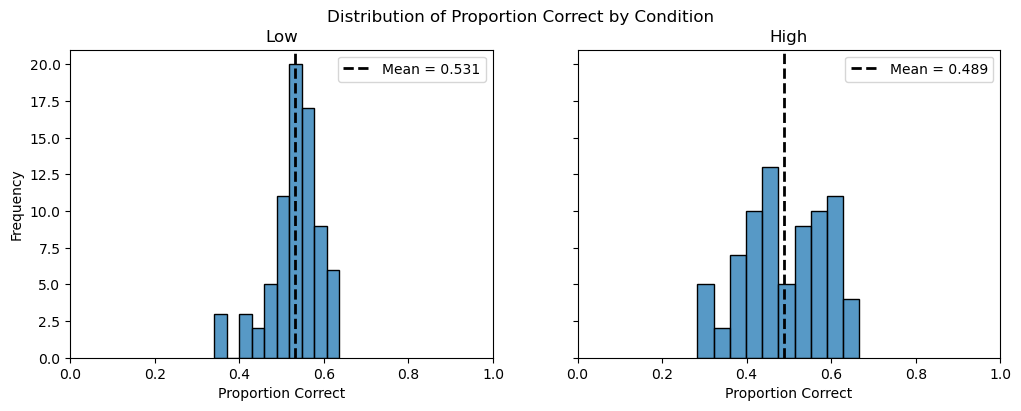

In [14]:
# Prop correct by condition
fig, axes = plt.subplots(1, 2, figsize=(12, 4), 
                         sharex = True, sharey=True)

dat_low = performance_by_id[performance_by_id['condition']=='Low']
dat_high = performance_by_id[performance_by_id['condition']=='High']

for ax, dat in zip(axes, [dat_low, dat_high]):
    sns.histplot(data=dat, x='prop_corr', bins=10, ax=ax)
    ax.axvline(dat['prop_corr'].mean(), 
               linestyle="--", color='black', linewidth=2, 
               label = f"Mean = {dat['prop_corr'].mean():.3f}")
    ax.set(xlabel='Proportion Correct', ylabel='Frequency', 
           title='Low' if dat is dat_low else 'High')
    ax.legend()
    ax.set_xlim(0, 1)

plt.suptitle("Distribution of Proportion Correct by Condition")
plt.show()

## Filter IDs

In [15]:
# exclude lowest 10% of subjects by accuracy and highest 10% by RT in each condition
threshold_acc = performance_by_id.groupby('condition', observed=True)['prop_corr'].quantile(0.1)
threshold_rt = performance_by_id.groupby('condition', observed=True)['mean_RT'].quantile(0.9)

print(f'Accuracy thresholds by condition:\n{threshold_acc}\n')
print(f'Reaction time thresholds by condition:\n{threshold_rt}\n')

performance_by_id['is_good_subj'] = performance_by_id.apply(lambda row: (row['prop_corr'] >= threshold_acc[row['condition']]) & 
                                                            (row['mean_RT'] <= threshold_rt[row['condition']]), 
                                                            axis=1)

print(f'Proportion of good subjects: {performance_by_id.is_good_subj.value_counts()[True] / performance_by_id.shape[0]:.2%}')

Accuracy thresholds by condition:
condition
High    0.370000
Low     0.458333
Name: prop_corr, dtype: float64

Reaction time thresholds by condition:
condition
High    2075.115000
Low     1717.401667
Name: mean_RT, dtype: float64

Proportion of good subjects: 81.58%


In [16]:
performance_by_id.groupby('condition', as_index=False).is_good_subj.value_counts()

,condition,is_good_subj,count
0,High,True,63
1,High,False,13
2,Low,True,61
3,Low,False,15


In [17]:
# # specify if it's a good subject
# performance_by_id['is_good_subj'] = np.where(
#     performance_by_id['dprime'] < 0.2, False, True
# )
# performance_by_id

In [18]:
# Merge it with the main data set
data_set = pd.merge(
    data_set,
    performance_by_id.loc[:,['condition', 'subject_id','is_good_subj']],
    how='left', on=['condition', 'subject_id']
)

# use only good subjects
filtered_data = data_set.loc[data_set['is_good_subj']==True]
filtered_data

,phase,block,trial_in_block,trial_in_exp,image_id,object_type,sub_category,category,response,is_correct,rt,condition,subject_id,object_type_detailed,is_good_subj
480,Train,1,1,1,121,Study,8,1,1,True,2248.0,Low,16,Study,True
481,Train,1,2,2,353,Study,23,3,3,True,2568.0,Low,16,Study,True
482,Train,1,3,3,16,Study,1,1,2,False,1077.0,Low,16,Study,True
483,Train,1,4,4,52,Study,4,1,2,False,1680.0,Low,16,Study,True
484,Train,1,5,5,280,Study,18,2,3,False,1860.0,Low,16,Study,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72955,Test,1,296,476,183,Novel,12,2,2,True,1371.0,Low,27,Novel_Both,True
72956,Test,1,297,477,47,Novel,3,1,1,True,1349.0,Low,27,Novel_Both,True
72957,Test,1,298,478,441,Novel,28,3,3,True,1375.0,Low,27,Novel_Both,True
72958,Test,1,299,479,72,Novel,5,1,1,True,1096.0,Low,27,Novel,True


# Accuracy Distribution in each Condition

In [19]:
acc_by_ID_df = (filtered_data
 .groupby(['condition', 'subject_id', 'object_type_detailed'], observed=True)
 .agg({'is_correct': 'mean', 'rt': 'mean'})
 .reset_index()
 .rename(columns={'is_correct': 'accuracy', 'rt': 'mean_RT'})
 )
acc_by_ID_df

,condition,subject_id,object_type_detailed,accuracy,mean_RT
0,High,1,Novel,0.354839,1396.064516
1,High,1,Study,0.490991,2337.558559
2,High,1,Novel_Both,0.436123,1788.797357
3,High,2,Novel,0.612903,1910.741935
4,High,2,Study,0.737089,2368.525822
...,...,...,...,...,...
367,Low,77,Study,0.715596,1516.389908
368,Low,77,Novel_Both,0.561947,921.234513
369,Low,9999999,Novel,0.548387,1067.709677
370,Low,9999999,Study,0.672811,1624.377880


## Prop Correct

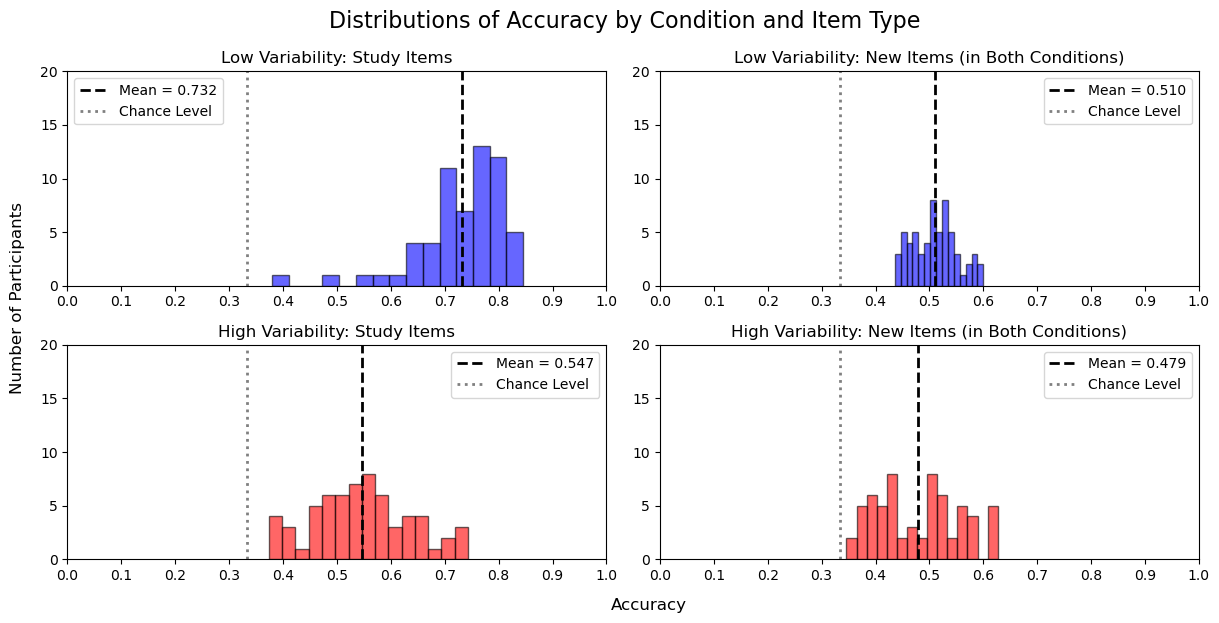

In [20]:
n_bins = 15
n_subj = 20

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

conditions = [('Low', 'blue'), ('High', 'red')]
item_types = [('Study', 'Study Items'), ('Novel_Both', 'New Items (in Both Conditions)')]

for row, (condition, color) in enumerate(conditions):
    for col, (item_type, item_label) in enumerate(item_types):
        ax = axes[row, col]
        
        data = acc_by_ID_df.loc[
            (acc_by_ID_df['condition'] == condition) & 
            (acc_by_ID_df['object_type_detailed'] == item_type), 
            'accuracy'
        ]
        mean_val = data.mean()
        
        ax.hist(data, bins=n_bins, color=color, alpha=0.6, edgecolor='black')
        ax.set_title(f'{condition} Variability: {item_label}')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, n_subj)
        ax.set_xticks(np.arange(0, 1.1, 0.1))
        ax.axvline(x=mean_val, color='black', linestyle='dashed', linewidth=2,
                   label=f'Mean = {mean_val:.3f}')
        ax.axvline(x=1/3, color='gray', linestyle='dotted', linewidth=2, label='Chance Level')
        ax.legend()

fig.text(0.52, 0, 'Accuracy', ha='center', va='top', fontsize=12)
fig.text(0, 0.5, 'Number of Participants', ha='right', va='center', rotation='vertical', fontsize=12)
fig.suptitle('Distributions of Accuracy by Condition and Item Type', fontsize=16)
plt.tight_layout()
plt.show()

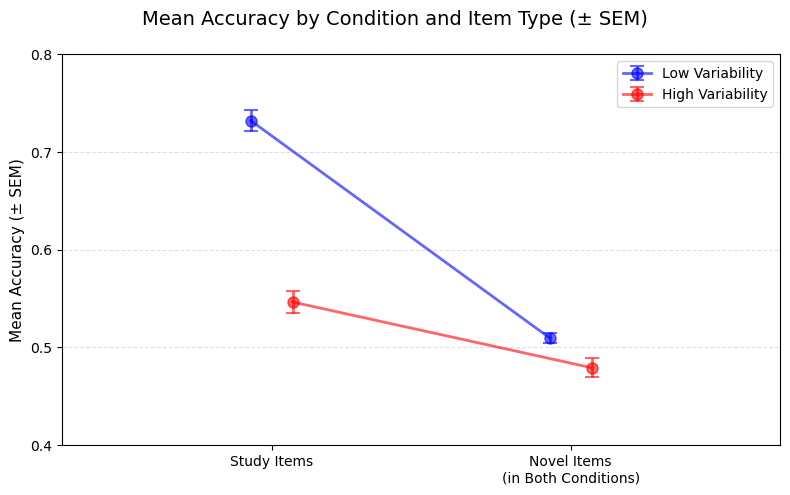

In [21]:
# Same plot but with error bars instead of histograms
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

conditions  = ['Low', 'High']
item_types  = ['Study', 'Novel_Both']
colors_cond = {'Low': 'blue', 'High': 'red'}
dodge       = {'Low': -0.07, 'High': 0.07}  
x_positions = {item: i for i, item in enumerate(item_types)}

for condition in conditions:
    means, sems, xs = [], [], []
    for item_type in item_types:
        subset = acc_by_ID_df.loc[
            (acc_by_ID_df['object_type_detailed'] == item_type) &
            (acc_by_ID_df['condition'] == condition)
        ]
        means.append(subset['accuracy'].mean())
        sems.append(subset['accuracy'].sem())
        xs.append(x_positions[item_type] + dodge[condition])

    ax.errorbar(
        xs, means, yerr=sems,
        label=f'{condition} Variability',
        color=colors_cond[condition],
        marker='o', markersize=8,
        linewidth=2, capsize=5, capthick=1.5, alpha=0.6
    )


ax.set_xticks(range(len(item_types)))
ax.set_xticklabels(['Study Items', 'Novel Items\n(in Both Conditions)'])
ax.set_xlim(-0.7, len(item_types)-0.3)
ax.set_ylim(0.4, 0.8)
ax.set_yticks(np.arange(0.4, 0.9, 0.1))
ax.set_ylabel('Mean Accuracy (± SEM)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Mean Accuracy by Condition and Item Type (± SEM)', fontsize=14)
plt.tight_layout()
plt.show()

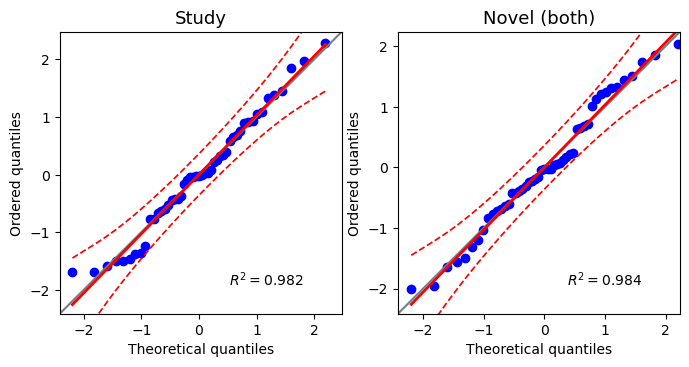

In [22]:
# t-test assumptions: normality of differences
t_test_acc_df_by_ID = acc_by_ID_df \
        .query("object_type_detailed != 'Novel'") \
        .pivot(index=['subject_id', 'object_type_detailed'], columns=['condition'], values='accuracy') \
        .reset_index()

diffs_Study = (t_test_acc_df_by_ID[t_test_acc_df_by_ID['object_type_detailed']== 'Study'].High - 
               t_test_acc_df_by_ID[t_test_acc_df_by_ID['object_type_detailed']== 'Study'].Low)
diffs_Novel = (t_test_acc_df_by_ID[t_test_acc_df_by_ID['object_type_detailed']== 'Novel_Both'].High - 
               t_test_acc_df_by_ID[t_test_acc_df_by_ID['object_type_detailed']== 'Novel_Both'].Low)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
pg.qqplot(diffs_Study, ax=axes[0])
axes[0].set_title('Study', fontsize=13)
pg.qqplot(diffs_Novel, ax=axes[1])
axes[1].set_title('Novel (both)', fontsize=13)
plt.show()

In [23]:
# t-test for High vs Low variability in Study and Novel items
print("="*20 + "T-test results" + "="*20)
item_types = ['Study', 'Novel_Both']
for item_type in item_types:
    print(f"\n\n{item_type.upper()}:")
    ttest_results = pg.ttest(
        t_test_acc_df_by_ID[t_test_acc_df_by_ID['object_type_detailed'] == item_type].Low,
        t_test_acc_df_by_ID[t_test_acc_df_by_ID['object_type_detailed'] == item_type].High,
        paired=True
    )
    print(ttest_results.to_string())

====================T-test results====================


STUDY:
                T  dof alternative         p_val          CI95  cohen_d  power       BF10
T_test  12.025963   48   two-sided  4.317235e-16  [0.16, 0.23]  2.26883    1.0  1.463e+13


NOVEL_BOTH:
               T  dof alternative     p_val         CI95   cohen_d     power   BF10
T_test  2.404956   48   two-sided  0.020079  [0.0, 0.06]  0.475491  0.903401  2.092


## RT

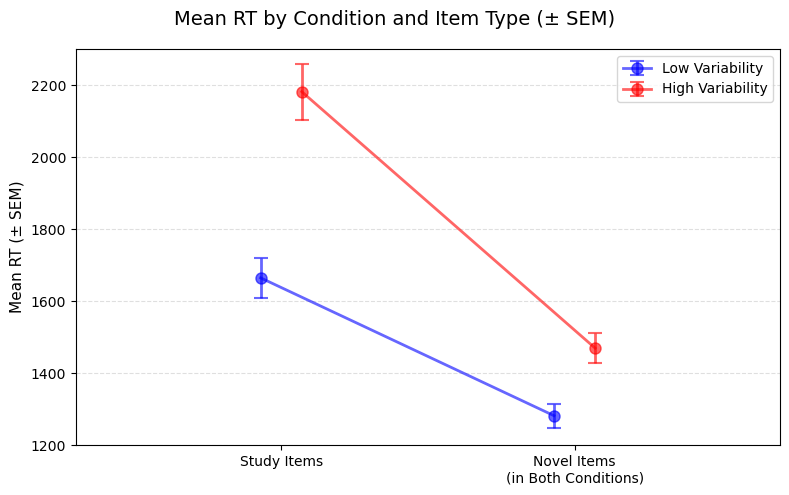

In [24]:
# Same plot but with error bars instead of histograms
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

conditions  = ['Low', 'High']
item_types  = ['Study', 'Novel_Both']
colors_cond = {'Low': 'blue', 'High': 'red'}
dodge       = {'Low': -0.07, 'High': 0.07}  
x_positions = {item: i for i, item in enumerate(item_types)}

for condition in conditions:
    means, sems, xs = [], [], []
    for item_type in item_types:
        subset = acc_by_ID_df.loc[
            (acc_by_ID_df['object_type_detailed'] == item_type) &
            (acc_by_ID_df['condition'] == condition)
        ]
        means.append(subset['mean_RT'].mean())
        sems.append(subset['mean_RT'].sem())
        xs.append(x_positions[item_type] + dodge[condition])

    ax.errorbar(
        xs, means, yerr=sems,
        label=f'{condition} Variability',
        color=colors_cond[condition],
        marker='o', markersize=8,
        linewidth=2, capsize=5, capthick=1.5, alpha=0.6
    )


ax.set_xticks(range(len(item_types)))
ax.set_xticklabels(['Study Items', 'Novel Items\n(in Both Conditions)'])
ax.set_xlim(-0.7, len(item_types)-0.3)
ax.set_ylim(1200, 2300)
ax.set_yticks(np.arange(1200, 2400, 200))
ax.set_ylabel('Mean RT (± SEM)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Mean RT by Condition and Item Type (± SEM)', fontsize=14)
plt.tight_layout()
plt.show()

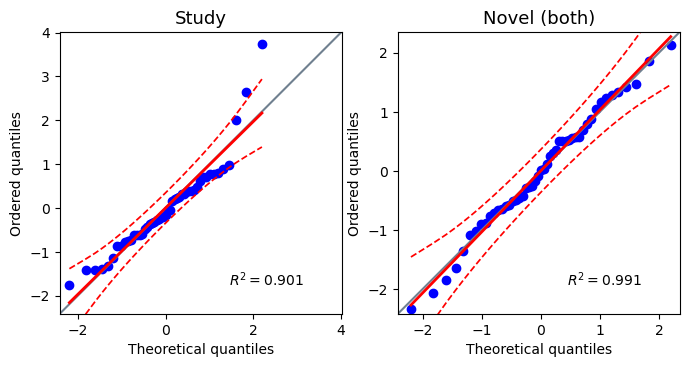

In [25]:
# t-test assumptions: normality of differences
t_test_acc_df_by_ID = acc_by_ID_df \
        .query("object_type_detailed != 'Novel'") \
        .pivot(index=['subject_id', 'object_type_detailed'], columns=['condition'], values='mean_RT') \
        .reset_index()

diffs_Study = (t_test_acc_df_by_ID[t_test_acc_df_by_ID['object_type_detailed']== 'Study'].High - 
               t_test_acc_df_by_ID[t_test_acc_df_by_ID['object_type_detailed']== 'Study'].Low)
diffs_Novel = (t_test_acc_df_by_ID[t_test_acc_df_by_ID['object_type_detailed']== 'Novel_Both'].High - 
               t_test_acc_df_by_ID[t_test_acc_df_by_ID['object_type_detailed']== 'Novel_Both'].Low)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
pg.qqplot(diffs_Study, ax=axes[0])
axes[0].set_title('Study', fontsize=13)
pg.qqplot(diffs_Novel, ax=axes[1])
axes[1].set_title('Novel (both)', fontsize=13)
plt.show()

In [26]:
# t-test for High vs Low variability in Study and Novel items
print("="*20 + "T-test results" + "="*20)
item_types = ['Study', 'Novel_Both']
for item_type in item_types:
    print(f"\n\n{item_type.upper()}:")
    ttest_results = pg.ttest(
        t_test_acc_df_by_ID[t_test_acc_df_by_ID['object_type_detailed'] == item_type].Low,
        t_test_acc_df_by_ID[t_test_acc_df_by_ID['object_type_detailed'] == item_type].High,
        paired=True
    )
    print(ttest_results.to_string())

====================T-test results====================


STUDY:
               T  dof alternative     p_val                CI95   cohen_d     power      BF10
T_test -5.189759   48   two-sided  0.000004  [-739.85, -326.66]  0.972048  0.999999  4295.347


NOVEL_BOTH:
               T  dof alternative     p_val               CI95  cohen_d     power    BF10
T_test -3.665794   48   two-sided  0.000616  [-291.47, -84.99]  0.66799  0.995611  44.292


# Condition Accuracy on Number of Training Items

Count how many instances from the same `SubCategory` were there in the study phase.

So, that's ok that a an item which is novel in both conditions has >0 train_count. This is because this exact item was never studied but objects from the same subcategory were!

In [27]:
train_counts = (data_set.loc[data_set['phase'] == 'Train']
 .groupby(['condition', 'subject_id', 'category'], observed=True)['sub_category']
 .value_counts()
 .reset_index(name='train_count')
 .assign(train_count = lambda df: df['train_count']/3) # divide by 3 because there're 3 repetitions of each of them
 )
train_counts

,condition,subject_id,category,sub_category,train_count
0,High,1,1,8,2.0
1,High,1,1,5,2.0
2,High,1,1,3,2.0
3,High,1,1,7,2.0
4,High,1,1,1,2.0
...,...,...,...,...,...
13675,Low,9999999,3,15,0.0
13676,Low,9999999,3,6,0.0
13677,Low,9999999,3,4,0.0
13678,Low,9999999,3,9,0.0


In [28]:
# Add train counts to the main data set
data_set = pd.merge(
    data_set,
    train_counts,
    how='left',  # keeps all rows in data_set
    on=['condition', 'subject_id', 'category', 'sub_category']
)
filtered_data = pd.merge(
    filtered_data,
    train_counts,
    how='left',  # keeps all rows in data_set
    on=['condition', 'subject_id', 'category', 'sub_category']
)

In [29]:
# Accuracy and RT by subject, condition, item type, and train count
acc_by_ID_df_tc = (filtered_data
 .groupby(['condition', 'subject_id', 'object_type_detailed', 'train_count'], observed=True)
 .agg({'is_correct': 'mean', 'rt': 'mean'})
 .reset_index()
 .rename(columns={'is_correct': 'accuracy', 'rt': 'mean_RT'})
 )
acc_by_ID_df_tc

,condition,subject_id,object_type_detailed,train_count,accuracy,mean_RT
0,High,1,Novel,2.0,0.354839,1396.064516
1,High,1,Study,2.0,0.490991,2337.558559
2,High,1,Novel_Both,2.0,0.436123,1788.797357
3,High,2,Novel,2.0,0.612903,1910.741935
4,High,2,Study,2.0,0.737089,2368.525822
...,...,...,...,...,...,...
1219,Low,9999999,Novel_Both,1.0,0.422535,1079.774648
1220,Low,9999999,Novel_Both,2.0,0.565217,1004.521739
1221,Low,9999999,Novel_Both,3.0,0.666667,965.190476
1222,Low,9999999,Novel_Both,4.0,0.482759,1082.103448


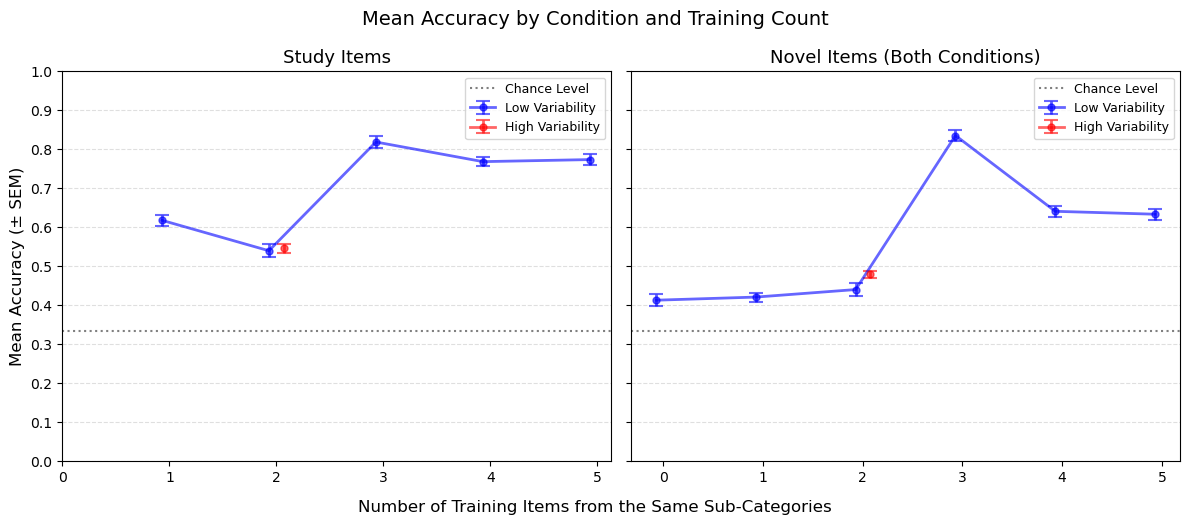

In [30]:
# Mean accuracy by condition, item type, and train count
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

conditions   = ['Low', 'High']
item_types   = [('Study', 'Study Items'), ('Novel_Both', 'Novel Items (Both Conditions)')]
colors_cond  = {'Low': 'blue', 'High': 'red'}
dodge       = {'Low': -0.07, 'High': 0.07}

for ax, (item_type, item_label) in zip(axes, item_types):
    for condition in conditions:
        subset = acc_by_ID_df_tc[
            (acc_by_ID_df_tc['condition'] == condition) &
            (acc_by_ID_df_tc['object_type_detailed'] == item_type)
        ]
        # Compute mean and SEM per Train_Count
        stats = (subset.groupby('train_count')['accuracy']
                       .agg(mean='mean', sem=lambda x: x.sem())
                       .reset_index())

        ax.errorbar(
            stats['train_count'] + dodge[condition], 
            stats['mean'],
            yerr=stats['sem'],
            label=f'{condition} Variability',
            color=colors_cond[condition],
            alpha=0.6,
            marker = 'o',
            markersize=5,
            linewidth=2,
            capsize=5,
            capthick=1.5,
        )

    ax.axhline(y=1/3, color='gray', linestyle='dotted', linewidth=1.5, label='Chance Level')
    ax.set_title(item_label, fontsize=13)
    ax.set_xticks(range(0, 6))
    ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

axes[0].set_ylabel('Mean Accuracy (± SEM)', fontsize=12)
fig.text(0.5, 0.0, 'Number of Training Items from the Same Sub-Categories', ha='center', va='top', fontsize=12)
fig.suptitle('Mean Accuracy by Condition and Training Count', fontsize=14)
plt.tight_layout()
plt.show()

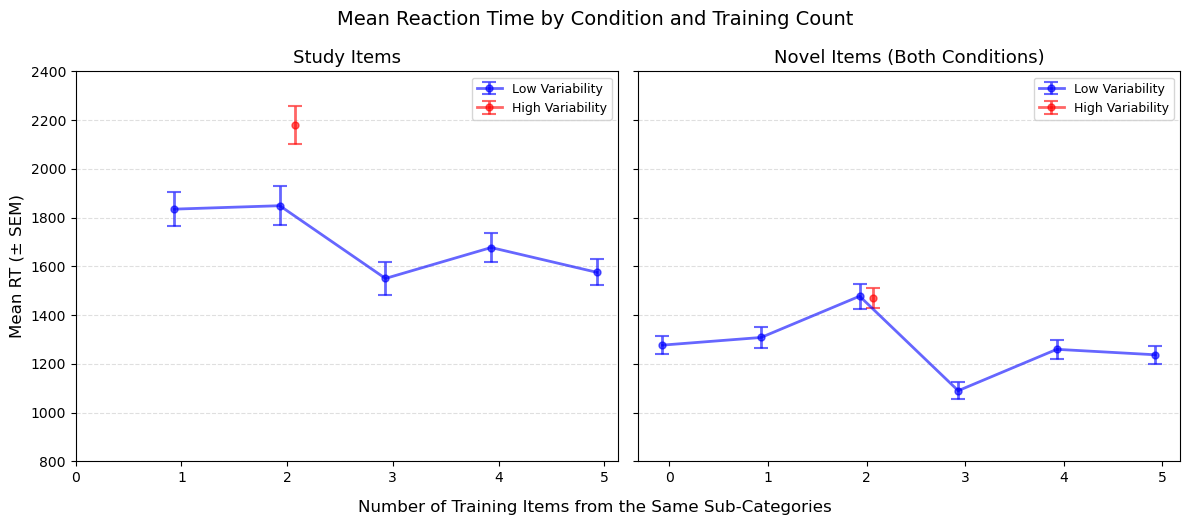

In [31]:
# Mean RT by condition, item type, and train count
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

conditions   = ['Low', 'High']
item_types   = [('Study', 'Study Items'), ('Novel_Both', 'Novel Items (Both Conditions)')]
colors_cond  = {'Low': 'blue', 'High': 'red'}
dodge       = {'Low': -0.07, 'High': 0.07}

for ax, (item_type, item_label) in zip(axes, item_types):
    for condition in conditions:
        subset = acc_by_ID_df_tc[
            (acc_by_ID_df_tc['condition'] == condition) &
            (acc_by_ID_df_tc['object_type_detailed'] == item_type)
        ]
        # Compute mean and SEM per Train_Count
        stats = (subset.groupby('train_count')['mean_RT']
                       .agg(mean='mean', sem=lambda x: x.sem())
                       .reset_index())

        ax.errorbar(
            stats['train_count'] + dodge[condition], 
            stats['mean'],
            yerr=stats['sem'],
            label=f'{condition} Variability',
            color=colors_cond[condition],
            alpha=0.6,
            marker = 'o',
            markersize=5,
            linewidth=2,
            capsize=5,
            capthick=1.5,
        )

    ax.set_title(item_label, fontsize=13)
    ax.set_xticks(range(0, 6))
    ax.set_yticks(np.arange(800, 2600, 200))
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

axes[0].set_ylabel('Mean RT (± SEM)', fontsize=12)
fig.text(0.5, 0.0, 'Number of Training Items from the Same Sub-Categories', ha='center', va='top', fontsize=12)
fig.suptitle('Mean Reaction Time by Condition and Training Count', fontsize=14)
plt.tight_layout()
plt.show()

In [32]:
# n_bins = 15
# n_subj = 20
# al = 0.6

# # Colors keyed by Train_Count (0–5)
# color_map = {
#     0: 'purple',
#     1: 'blue',
#     2: 'red',
#     3: 'green',
#     4: 'orange',
#     5: 'brown'
# }

# # Mapping for nicer subplot titles
# item_name_map = {
#     'Study': r'$\bf{Study}$ Items',
#     'Novel_Both': r'$\bf{Novel}$ Items (in both conditions)'
# }

# train_count_map = lambda x: rf'$\bf{{{x}}}$ Training Items from Sub-categories'

# # Define plotting plan: (condition, item_type, list of Train_Counts)
# plot_plan = [
#     ('Low', 'Study',      list(range(1, 6))),
#     ('Low', 'Novel_Both', list(range(0, 6))),
#     ('High', 'Study',     [2]),
#     ('High', 'Novel_Both',[2])
# ]

# fig_rows, fig_cols = 5, 3
# fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(15, 15))
# axes = axes.flatten()

# ax_idx = 0

# for condition, item_type, train_counts in plot_plan:
#     for train_count in train_counts:
#         if ax_idx >= len(axes):
#             break

#         # Skip one subplot so Low-Novel-0 starts on a new row
#         if condition == 'Low' and item_type == 'Novel_Both' and train_count == 0:
#             ax_idx += 1

#         ax = axes[ax_idx]
#         data = acc_by_ID_df_tc.loc[
#             (acc_by_ID_df_tc['condition'] == condition) &
#             (acc_by_ID_df_tc['Old_New_item_detailed'] == item_type) &
#             (acc_by_ID_df_tc['Train_Count'] == train_count),
#             'Accuracy'
#         ]
#         if len(data) == 0:
#             ax_idx += 1
#             continue

#         color = color_map[train_count]  # same train_count → same color, always

#         ax.hist(data, bins=n_bins, color=color, alpha=al, edgecolor='black')
#         ax.axvline(data.mean(), color=color, linestyle='dashed', linewidth=2,
#                    label=f'Mean Accuracy = {data.mean():.3f}')
#         ax.axvline(1/3, color='gray', linestyle='dotted', linewidth=2, label='Chance Level')

#         ax.set_xlim(0, 1)
#         ax.set_ylim(0, n_subj)
#         ax.set_xticks(np.arange(0, 1.1, 0.1))
#         ax.set_title(f'$\\bf{{{condition}}}$ Variability\n{item_name_map[item_type]}\n{train_count_map(train_count)}', fontsize=8)
#         ax.legend(fontsize=8)

#         ax_idx += 1

# # Remove unused axes
# for j in range(ax_idx, len(axes)):
#     fig.delaxes(axes[j])
# fig.delaxes(axes[5])

# fig.text(0.52, 0, 'Accuracy', ha='center', va='top', fontsize=12)
# fig.text(0, 0.5, 'Number of Participants', ha='right', va='center', rotation='vertical', fontsize=12)
# fig.suptitle('Distributions of Accuracy by Condition, Item Type\nand Number of Training Items in the Category', fontsize=16)
# plt.tight_layout()
# plt.subplots_adjust(top=0.9)
# plt.show()

# Models

Different people saw different test items (even in the same condition)

In [33]:
# test data set
filtered_data_test = filtered_data.query('phase == "Test"')
filtered_data_test

,phase,block,trial_in_block,trial_in_exp,image_id,object_type,sub_category,category,response,is_correct,rt,condition,subject_id,object_type_detailed,is_good_subj,train_count
180,Test,1,1,181,202,Novel,13,2,2,True,2185.0,Low,16,Novel_Both,True,1.0
181,Test,1,2,182,186,Novel,12,2,1,False,4960.0,Low,16,Novel,True,1.0
182,Test,1,3,183,445,Novel,28,3,3,True,1360.0,Low,16,Novel_Both,True,1.0
183,Test,1,4,184,250,Study,16,2,2,True,957.0,Low,16,Study,True,3.0
184,Test,1,5,185,383,Novel,24,3,1,False,1292.0,Low,16,Novel_Both,True,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59515,Test,1,296,476,183,Novel,12,2,2,True,1371.0,Low,27,Novel_Both,True,1.0
59516,Test,1,297,477,47,Novel,3,1,1,True,1349.0,Low,27,Novel_Both,True,5.0
59517,Test,1,298,478,441,Novel,28,3,3,True,1375.0,Low,27,Novel_Both,True,1.0
59518,Test,1,299,479,72,Novel,5,1,1,True,1096.0,Low,27,Novel,True,3.0


In [34]:
print("Test phase:")
print(f"N unique items in High cond: {data_set.query(' phase == "Test" and condition == "High" ').image_id.nunique()}")
print(f"N unique items in Low cond: {data_set.query(' phase == "Test" and condition == "Low" ').image_id.nunique()}")

Test phase:
N unique items in High cond: 480
N unique items in Low cond: 480


In [35]:
print("Study phase:")
print(f"N unique items in High cond: {data_set.query(' phase == "Train" and condition == "High" ').image_id.nunique()}")
print(f"N unique items in Low cond: {data_set.query(' phase == "Train" and condition == "Low" ').image_id.nunique()}")

Study phase:
N unique items in High cond: 60
N unique items in Low cond: 60


In [ ]:
# Read MDS solution
mds_solution = pd.read_csv('https://raw.githubusercontent.com/DaniilAzarov123/Rocks_Database/main/info/Rocks480_MDS8_solution.csv') # pd.read_csv('data_processed/MDS8_solution.csv')
mds_coords = mds_solution.set_index('image_id').iloc[:, :8]
mds_coords

,dim1,dim2,dim3,dim4,dim5,dim6,dim7,dim8
image_id,,,,,,,,
1,-2.757,-1.594,1.052,0.768,1.343,1.711,1.795,0.809
2,2.001,-0.754,1.405,-1.382,-1.384,0.976,-0.067,1.972
3,0.261,-0.508,-2.962,-0.608,0.009,-0.191,2.720,-1.224
4,0.382,-0.027,-0.148,-1.899,-1.948,1.862,0.968,0.986
5,0.288,2.013,-1.102,-1.285,0.344,-0.009,2.696,-0.174
...,...,...,...,...,...,...,...,...
476,0.749,-3.021,-1.908,-1.689,-0.493,4.441,-0.122,1.618
477,-0.054,-2.743,-1.435,-2.903,0.315,3.161,1.833,1.288
478,0.007,-2.077,-4.012,-1.633,-0.366,2.558,4.210,-0.060


In [39]:
# Test and Study items from each category

# ========== Study-Low ==========
study_items_low_1 =np.sort(data_set.loc[((data_set['phase'] == 'Train') &
                                         (data_set['condition'] == 'Low') &
                                         (data_set['category'] == 1)), 
                                        'image_id'].unique())
study_items_low_2 =np.sort(data_set.loc[((data_set['phase'] == 'Train') &
                                         (data_set['condition'] == 'Low') &
                                         (data_set['category'] == 2)), 
                                        'image_id'].unique())
study_items_low_3 =np.sort(data_set.loc[((data_set['phase'] == 'Train') &
                                         (data_set['condition'] == 'Low') &
                                         (data_set['category'] == 3)), 
                                        'image_id'].unique())

# ========== Study-High ==========
study_items_high_1 =np.sort(data_set.loc[((data_set['phase'] == 'Train') &
                                         (data_set['condition'] == 'High') &
                                         (data_set['category'] == 1)), 
                                        'image_id'].unique())
study_items_high_2 =np.sort(data_set.loc[((data_set['phase'] == 'Train') &
                                         (data_set['condition'] == 'High') &
                                         (data_set['category'] == 2)), 
                                        'image_id'].unique())
study_items_high_3 =np.sort(data_set.loc[((data_set['phase'] == 'Train') &
                                         (data_set['condition'] == 'High') &
                                         (data_set['category'] == 3)), 
                                        'image_id'].unique())

# ========== All test items ==========
all_test_items = np.sort(filtered_data_test['image_id'].unique())

In [40]:
# Calculate Euclidean distances between test items and study items in MDS space
study_items_dict = {
    'Low': {
        1: study_items_low_1,
        2: study_items_low_2,
        3: study_items_low_3
    },
    'High': {
        1: study_items_high_1,
        2: study_items_high_2,
        3: study_items_high_3
    }
}

conditions = ['Low', 'High']
categories = [1, 2, 3]
distances_dict = {}

for cond in conditions:
    distances_dict[cond] = {}
    for cat in categories:
        study_items = study_items_dict[cond][cat]
        dist_mat = np.linalg.norm(
            mds_coords.loc[all_test_items].values[:, None] - 
            mds_coords.loc[study_items].values[None, :],
            axis=2)
        distances_dict[cond][cat] = pd.DataFrame(dist_mat, index=all_test_items, columns=study_items)

In [ ]:
# Read distinctiveness ratings
# dist_ratings_df = pd.read_csv('rocks_distinctiveness_ratings.csv')
# dist_ratings_df.set_index('image_id', inplace=True)
# dist_ratings_df

In [ ]:
# # transform similarity matrix based on distinctiveness
# def transform_similarity_matrix(alpha, beta, similarity_matrix, 
#                                 distinctiveness_ratings_df = dist_ratings_df):

#     transformed = similarity_matrix.copy()

#     # Iterate through each row
#     for row_id in transformed.index:
#         # Get distinctiveness for this row's image
#         distinct_i = distinctiveness_ratings_df.loc[row_id,'distinct_rating']
        
#         # Iterate through each column
#         for col_id in transformed.columns:
#             s_ij = similarity_matrix.loc[row_id, col_id]
            
#             if row_id == col_id:
#                 # Self-similarity case: exp(beta * distinct_i)
#                 # Since s_ii = 1
#                 transformed.loc[row_id, col_id] = np.exp(beta * distinct_i)
#             else:
#                 # Similarity between different items (item i and item j) case
#                 # s_ij * exp(-alpha * distinct_i)
#                 transformed.loc[row_id, col_id] = np.exp(-alpha * distinct_i) * s_ij
#     return transformed

## GCM

In [ ]:
# # Needs c parameter, test data, and distances in MDS space
# # returns predicted categories, and 
# # a data frame with probabilities for each category
# def GCM(parameters, data_test, distances_dict=distances_dict):

#     c = parameters[0]
#     conditions = ['Low', 'High']
#     categories = [1, 2, 3]
    
#     # Step 1: compute E_iA for every test_image_id in (condition, category)
#     evidence_dict = {}
#     for cond in conditions:
#         evidence_dict[cond] = {}
#         for cat in categories:
#             dist_mat = distances_dict[cond][cat]           # shape: (480, n_study_in_cat)
#             sim_mat  = np.exp(-c * dist_mat)               # same shape, similarity
#             evidence_dict[cond][cat] = sim_mat.sum(axis=1) # Series: summed similarity per test image_id

#     # Step 2: for each (condition, test_image_id), compute P(Category | image_id)
#     records = []
#     for cond in conditions:
#         # Total evidence = sum across all 3 categories
#         total_evidence = sum(evidence_dict[cond][cat] for cat in categories)  # Series over test image_ids
        
#         for cat in categories:
#             p_cat = evidence_dict[cond][cat] / total_evidence  # P(cat | item) for all test image_ids
            
#             for image_id in p_cat.index:
#                 records.append({
#                     'condition': cond,
#                     'image_id':      image_id,
#                     'category':  cat,
#                     'p_correct': p_cat.loc[image_id]
#                 })
    
#     predictions_df = pd.DataFrame(records)
#     # wide format
#     predictions_df_wide = predictions_df.pivot(index = ['condition','image_id'], columns = 'category', values = 'p_correct').reset_index()
#     predictions_df_wide['cat_pred'] = predictions_df_wide.iloc[:,-3:].idxmax(axis=1)
#     # rename columns
#     colnames = predictions_df_wide.iloc[:,-4:-1].columns
#     predictions_df_wide.columns = list(predictions_df_wide.columns[0:2]) + ['GCM_cat_' + str(col) +'_pred_prob' for col in colnames] + list(predictions_df_wide.columns[-1:])
#     predictions_df_wide
    
#     # Step 3: merge onto data_test on condition + image_id + Category
#     # This matches the true category of each test item to its predicted probability
#     result_df = data_test \
#         .merge(predictions_df_wide, on=['condition', 'image_id'], how='left') \
#             .loc[:,['subject_id','condition','image_id',
#                     'GCM_cat_1_pred_prob','GCM_cat_2_pred_prob',
#                     'GCM_cat_3_pred_prob', 'cat_pred']]
    
#     return result_df['cat_pred'], result_df

In [ ]:
# # Needs c, k, alpha, beta parameters, test data, and distances in MDS space
# # returns predicted categories, and 
# # a data frame with probabilities for each category
# def GCM(parameters, 
#         data_test = filtered_data_test, 
#         distances_dict = distances_dict,
#         distinctiveness_ratings_df = dist_ratings_df):

#     # unpack parameters
#     # convert to list of Python scalars first
#     params = [float(p) for p in parameters]
#     if len(params)==1:
#         c, k = params + [0]
#     elif len(params)==2:
#         c, k = params
#     elif len(params)==4:
#         c, k, alpha, beta = params
    
    
#     conditions = data_test.condition.unique().tolist()
#     categories = [1, 2, 3]
    
#     # Step 1: compute E_iA for every test_image_id in (condition, category)
#     evidence_dict = {}
#     for cond in conditions:
#         evidence_dict[cond] = {}
#         for cat in categories:
#             dist_mat = distances_dict[cond][cat]           # shape: (480, n_study_in_cat)
#             sim_mat  = np.exp(-c * dist_mat)               # same shape, similarity
            
#             # if account for distinctiveness
#             if len(params) > 2:
#                 transformed_sim_mat = transform_similarity_matrix(alpha, beta, 
#                                                                 sim_mat, distinctiveness_ratings_df)
#                 evidence_dict[cond][cat] = transformed_sim_mat.sum(axis=1) # Series: summed similarity per test image_id
#             else:
#                 evidence_dict[cond][cat] = sim_mat.sum(axis=1)

#     # Step 2: for each (condition, test_image_id), compute P(Category | image_id)
#     records = []
#     for cond in conditions:
#         # Total evidence = sum across all 3 categories
#         total_evidence = sum(evidence_dict[cond][cat] for cat in categories)  # Series over test image_ids
        
#         for cat in categories:
#             p_cat = (evidence_dict[cond][cat] + k) / (total_evidence + 3*k)  # P(cat | item) for all test image_ids
            
#             for image_id in p_cat.index:
#                 records.append({
#                     'condition': cond,
#                     'image_id':  image_id,
#                     'category':  cat,
#                     'p_correct': p_cat.loc[image_id]
#                 })
    
#     predictions_df = pd.DataFrame(records)
#     # wide format
#     predictions_df_wide = predictions_df.pivot(index = ['condition','image_id'], columns = 'category', values = 'p_correct').reset_index()
#     predictions_df_wide['predicted_cat'] = predictions_df_wide.iloc[:,-3:].idxmax(axis=1)
#     # rename columns
#     colnames = predictions_df_wide.iloc[:,-4:-1].columns
#     predictions_df_wide.columns = list(predictions_df_wide.columns[0:2]) + ['cat_' + str(col) +'_pred_prob' for col in colnames] + list(predictions_df_wide.columns[-1:])
#     predictions_df_wide
    
#     # Step 3: merge onto data_test on condition + image_id + Category
#     # This matches the true category of each test item to its predicted probability
#     result_df = data_test \
#         .merge(predictions_df_wide, on=['condition', 'image_id'], how='left') \
#             .loc[:,['subject_id','condition','image_id',
#                     'cat_1_pred_prob','cat_2_pred_prob',
#                     'cat_3_pred_prob', 'predicted_cat']]
    
#     return result_df['predicted_cat'], result_df

In [42]:
# ── Build image_id → sub_category/category lookup ─────────────────────────
image_info = (data_set[['image_id', 'sub_category', 'category']]
              .drop_duplicates()
              .set_index('image_id'))

In [43]:

# ── Updated GCM ───────────────────────────────────────────────────────────
def GCM(parameters,
        data_test       = filtered_data_test,
        distances_dict  = distances_dict,
        image_info      = image_info):

    params = [float(p) for p in parameters]

    if len(params) == 1:
        c_within, c_between, k = params[0], params[0], 0
    elif len(params) == 2:
        c_within, c_between, k = params[0], params[1], 0   # c_within, c_between, no k
    elif len(params) == 3:
        c_within, c_between, k = params                     # c_within, c_between, k
    else:
        raise ValueError(f'Expected 1, 2, or 3 parameters, got {len(params)}')

    conditions = data_test.condition.unique().tolist()
    categories = [1, 2, 3]

    # Step 1: compute E_iA for every test_image_id in (condition, category)
    evidence_dict = {}
    for cond in conditions:
        evidence_dict[cond] = {}
        for cat in categories:
            dist_mat   = distances_dict[cond][cat]          # (n_test, n_study)
            test_ids   = dist_mat.index
            study_ids  = dist_mat.columns

            # Sub-category lookup for test and study items
            test_subcats  = image_info.loc[test_ids,  'sub_category'].astype(int).values  # (n_test,)
            study_subcats = image_info.loc[study_ids, 'sub_category'].astype(int).values  # (n_study,)

            # Within-subcategory mask: True where test and study share the same sub_category
            within_mask = (test_subcats[:, None] == study_subcats[None, :])   # (n_test, n_study)

            # Apply c_within or c_between depending on the mask
            sim_mat = np.where(
                within_mask,
                np.exp(-c_within  * dist_mat.values),
                np.exp(-c_between * dist_mat.values)
            )

            evidence_dict[cond][cat] = sim_mat.sum(axis=1)  # (n_test,) numpy array

    # Step 2: compute P(Category | image_id)
    records = []
    for cond in conditions:
        total_evidence = sum(evidence_dict[cond][cat] for cat in categories)
        test_ids       = distances_dict[cond][1].index

        for cat in categories:
            p_cat = (evidence_dict[cond][cat] + k) / (total_evidence + 3 * k)
            for image_id, p in zip(test_ids, p_cat):
                records.append({
                    'condition': cond,
                    'image_id':  image_id,
                    'category':  cat,
                    'p_correct': p
                })

    predictions_df      = pd.DataFrame(records)
    predictions_df_wide = predictions_df.pivot(
        index=['condition', 'image_id'], columns='category', values='p_correct'
    ).reset_index()
    predictions_df_wide['predicted_cat'] = predictions_df_wide.iloc[:, -3:].idxmax(axis=1)
    colnames = predictions_df_wide.iloc[:, -4:-1].columns
    predictions_df_wide.columns = (
        list(predictions_df_wide.columns[:2]) +
        ['cat_' + str(col) + '_pred_prob' for col in colnames] +
        list(predictions_df_wide.columns[-1:])
    )

    result_df = data_test \
        .merge(predictions_df_wide, on=['condition', 'image_id'], how='left') \
        .loc[:, ['subject_id', 'condition', 'image_id',
                 'cat_1_pred_prob', 'cat_2_pred_prob',
                 'cat_3_pred_prob', 'predicted_cat']]

    return result_df['predicted_cat'], result_df

In [44]:
# GCM with c and k
# use it for single c and k 
def GCM_ck(parameters, 
           data_test=filtered_data_test,
           distances_dict=distances_dict, 
           image_info=image_info):
    c, k = float(parameters[0]), float(parameters[1])
    return GCM([c, c, k], data_test, distances_dict, image_info)

# Optimization

In [ ]:
# # Store fit results here
# models_fits = {}

In [ ]:
# # NLL
# def NLL(parameters, 
#         model,
#         data_test=filtered_data_test, 
#         distances_dict=distances_dict,
#         distinctiveness_ratings_df=dist_ratings_df,
#         prob_cat_map = {
#             1: 'cat_1_pred_prob',
#             2: 'cat_2_pred_prob',
#             3: 'cat_3_pred_prob'}):
    
#     _, result_df = model(parameters, data_test, 
#                          distances_dict, distinctiveness_ratings_df)
    
#     # For each row, grab the predicted probability of the category the subject actually responded with
#     # Response contains the subject's answer (1, 2, or 3)

    
#     # Vectorized: pick the predicted probability matching the subject's response
#     result_df = result_df.merge(data_test[['subject_id', 'condition', 'image_id', 'response']],
#                                 on=['subject_id', 'condition', 'image_id'], how='left')
    
#     result_df['p_response'] = result_df.apply(
#         lambda row: row[prob_cat_map[row['response']]], axis=1
#     )
    
#     # Clip to avoid log(0)
#     result_df['p_response'] = result_df['p_response'].clip(lower=1e-10)
    
#     NLL = -np.log(result_df['p_response']).sum()
    
#     return NLL

In [ ]:
# NLL([1.1], GCM)

In [ ]:
# # ── GCM-c (single c) ──────────────────────────────────────────────────────
# initial_params = [0.1]
# bounds = [(None, None)]
# fit = minimize(
#     NLL, x0=initial_params, args=(GCM,),
#     method='Nelder-Mead',bounds=bounds,
#     options={'maxiter': 1000, 'disp': True}
# )
# models_fits['GCM_c'] = {'fit': fit, 'per_condition': False}
# print(f'GCM_c: c={fit.x[0]:.3f}, NLL={fit.fun:.3f}')

In [ ]:
# # ── GCM-c (c per condition) ───────────────────────────────────────────────
# initial_params = [0.1]
# bounds = [(None, None)]

# cond_fits = {}
# for cond in ['Low', 'High']:
#     data_cond           = filtered_data_test[filtered_data_test['condition'] == cond]
#     distances_dict_cond = {cond: distances_dict[cond]}
#     fit = minimize(
#         NLL, x0=initial_params, args=(GCM, data_cond, distances_dict_cond),
#         method='Nelder-Mead',bounds=bounds,
#         options={'maxiter': 1000, 'disp': True}
#     )
#     cond_fits[cond] = fit
#     print(f'GCM_c_per_cond [{cond}]: c={fit.x[0]:.3f}, NLL={fit.fun:.3f}')
# models_fits['GCM_c_per_cond'] = {'fit': cond_fits, 'per_condition': True}

In [ ]:
# # ── GCM-ck (single c and k) ───────────────────────────────────────────────
# initial_params = [0.1, 0.1]
# bounds = [(None, None), (None, None)]
# fit = minimize(
#     NLL, x0=initial_params, args=(GCM,),
#     method='Nelder-Mead',bounds=bounds,
#     options={'maxiter': 1000, 'disp': True}
# )
# models_fits['GCM_ck'] = {'fit': fit, 'per_condition': False}
# print(f'GCM_ck: c={fit.x[0]:.3f}, k={fit.x[1]:.3f}, NLL={fit.fun:.3f}')

In [ ]:
# # ── GCM-ck (c and k per condition) ────────────────────────────────────────
# initial_params = [0.1, 0.1]
# bounds = [(None, None), (None, None)]

# cond_fits = {}
# for cond in ['Low', 'High']:
#     data_cond           = filtered_data_test[filtered_data_test['condition'] == cond]
#     distances_dict_cond = {cond: distances_dict[cond]}
#     fit = minimize(
#         NLL, x0=initial_params, args=(GCM, data_cond, distances_dict_cond),
#         method='Nelder-Mead',bounds=bounds,
#         options={'maxiter': 1000, 'disp': True}
#     )
#     cond_fits[cond] = fit
#     print(f'GCM_ck_per_cond [{cond}]: c={fit.x[0]:.3f}, k={fit.x[1]:.3f}, NLL={fit.fun:.3f}')
# models_fits['GCM_ck_per_cond'] = {'fit': cond_fits, 'per_condition': True}

In [ ]:
# initial_params = [0.1, 0.1, 0.1, 0.1]  # c, k, alpha, beta

# bounds = [
#     (None, None),      # c >= 0
#     (None, None),      # k >= 0
#     (None, None),      # alpha >= 0
#     (None, None),      # beta >= 0
# ]
# GCM_ckab_fit = minimize(
#     NLL,
#     x0=initial_params,
#     args=(GCM,),
#     method='Nelder-Mead',
#     bounds=bounds,
#     options={'maxiter': 1000, 'disp': True}
# )
# print(f'Best c: {GCM_ckab_fit.x[0]:.3f}')
# print(f'Best k: {GCM_ckab_fit.x[1]:.3f}')
# print(f'Best alpha: {GCM_ckab_fit.x[2]:.3f}')
# print(f'Best beta: {GCM_ckab_fit.x[3]:.3f}')
# print(f'NLL: {GCM_ckab_fit.fun:.3f}')

## c_w, c_b, k

In [45]:
def NLL(parameters,
        model,
        data_test      = filtered_data_test,
        distances_dict = distances_dict,
        image_info     = image_info,
        prob_cat_map   = {1: 'cat_1_pred_prob',
                          2: 'cat_2_pred_prob',
                          3: 'cat_3_pred_prob'}):

    _, result_df = model(parameters, data_test, distances_dict, image_info)

    result_df = result_df.merge(
        data_test[['subject_id', 'condition', 'image_id', 'response']],
        on=['subject_id', 'condition', 'image_id'], how='left'
    )

    result_df['p_response'] = result_df.apply(
        lambda row: row[prob_cat_map[row['response']]], axis=1
    )
    result_df['p_response'] = result_df['p_response'].clip(lower=1e-10)

    return -np.log(result_df['p_response']).sum()

In [ ]:
# ── Model fits ────────────────────────────────────────────────────────────
models_fits = {}

In [ ]:
# GCM-c: single c
fit = minimize(NLL, 
               x0=[0.1], 
               args=(GCM,),
               method='Nelder-Mead', 
               options={'maxiter': 1000, 'disp': True})

models_fits['GCM_c'] = {'fit': fit, 'per_condition': False}
print(f"GCM_c:     c={fit.x[0]:.3f}, NLL={fit.fun:.3f}")


Optimization terminated successfully.
         Current function value: 34471.770757
         Iterations: 19
         Function evaluations: 38
GCM_c:     c=0.807, NLL=34471.771


In [ ]:
# GCM-c per condition
cond_fits = {}
for cond in ['Low', 'High']:
    data_cond           = filtered_data_test[filtered_data_test['condition'] == cond]
    distances_dict_cond = {cond: distances_dict[cond]}
    fit = minimize(NLL, 
                   x0=[0.1], 
                   args=(GCM, data_cond, distances_dict_cond, image_info),
                   method='Nelder-Mead', 
                   options={'maxiter': 1000, 'disp': True})
    cond_fits[cond] = fit
    print(f"GCM_c_per_cond [{cond}]: c={fit.x[0]:.3f}, NLL={fit.fun:.3f}")

models_fits['GCM_c_per_cond'] = {'fit': cond_fits, 'per_condition': True}

Optimization terminated successfully.
         Current function value: 15202.772474
         Iterations: 20
         Function evaluations: 40
GCM_c_per_cond [Low]: c=1.046, NLL=15202.772
Optimization terminated successfully.
         Current function value: 18859.529178
         Iterations: 19
         Function evaluations: 38
GCM_c_per_cond [High]: c=0.666, NLL=18859.529


In [ ]:
# GCM-ck: single c + k
fit = minimize(NLL, 
               x0=[0.1, 0.1], 
               args=(GCM_ck,),
               method='Nelder-Mead', 
               options={'maxiter': 1000, 'disp': True})

models_fits['GCM_ck'] = {'fit': fit, 'per_condition': False}
print(f"GCM_ck:    c={fit.x[0]:.3f}, k={fit.x[1]:.3f}, NLL={fit.fun:.3f}")

Optimization terminated successfully.
         Current function value: 34431.550345
         Iterations: 91
         Function evaluations: 169
GCM_ck:    c=0.762, k=-0.021, NLL=34431.550


In [ ]:
# GCM-ck per condition
cond_fits = {}
for cond in ['Low', 'High']:
    data_cond           = filtered_data_test[filtered_data_test['condition'] == cond]
    distances_dict_cond = {cond: distances_dict[cond]}
    fit = minimize(NLL, 
                   x0=[0.1, 0.1], 
                   args=(GCM_ck, data_cond, distances_dict_cond, image_info),
                   method='Nelder-Mead', 
                   options={'maxiter': 1000, 'disp': True})
    cond_fits[cond] = fit
    print(f"GCM_ck_per_cond [{cond}]: c={fit.x[0]:.3f}, k={fit.x[1]:.3f}, NLL={fit.fun:.3f}")

models_fits['GCM_ck_per_cond'] = {'fit': cond_fits, 'per_condition': True}

Optimization terminated successfully.
         Current function value: 15200.162528
         Iterations: 103
         Function evaluations: 192
GCM_ck_per_cond [Low]: c=1.030, k=-0.001, NLL=15200.163
Optimization terminated successfully.
         Current function value: 18838.022763
         Iterations: 66
         Function evaluations: 130
GCM_ck_per_cond [High]: c=0.599, k=-0.095, NLL=18838.023


In [ ]:
# GCM-cwb: c_within + c_between, no k — x0 has 2 elements now
fit = minimize(NLL, x0=[0.1, 0.1], args=(GCM,),
               method='Nelder-Mead', options={'maxiter': 1000, 'disp': True})
models_fits['GCM_cwb'] = {'fit': fit, 'per_condition': False, 'model_fn': GCM}
print(f"GCM_cwb: c_w={fit.x[0]:.3f}, c_b={fit.x[1]:.3f}, NLL={fit.fun:.3f}")

Optimization terminated successfully.
         Current function value: 34235.791142
         Iterations: 50
         Function evaluations: 95
GCM_cwb: c_w=0.512, c_b=0.750, NLL=34235.791


In [ ]:
# GCM-cwb per condition
cond_fits = {}
for cond in ['Low', 'High']:
    data_cond           = filtered_data_test[filtered_data_test['condition'] == cond]
    distances_dict_cond = {cond: distances_dict[cond]}
    fit = minimize(NLL, x0=[0.1, 0.1],
                   args=(GCM, data_cond, distances_dict_cond, image_info),
                   method='Nelder-Mead', options={'maxiter': 1000, 'disp': True})
    cond_fits[cond] = fit
    print(f"GCM_cwb_per_cond [{cond}]: c_w={fit.x[0]:.3f}, c_b={fit.x[1]:.3f}, NLL={fit.fun:.3f}")
models_fits['GCM_cwb_per_cond'] = {'fit': cond_fits, 'per_condition': True, 'model_fn': GCM}

Optimization terminated successfully.
         Current function value: 15135.494315
         Iterations: 53
         Function evaluations: 102
GCM_cwb_per_cond [Low]: c_w=0.801, c_b=1.003, NLL=15135.494
Optimization terminated successfully.
         Current function value: 18688.877017
         Iterations: 60
         Function evaluations: 115
GCM_cwb_per_cond [High]: c_w=0.329, c_b=0.597, NLL=18688.877


In [ ]:
# GCM-cwb-k: c_within + c_between + k
fit = minimize(NLL, 
               x0=[0.1, 0.1, 0.1], 
               args=(GCM,),
               method='Nelder-Mead', 
               options={'maxiter': 1000, 'disp': True})
models_fits['GCM_cwb_k'] = {'fit': fit, 'per_condition': False, 'model_fn': GCM}
print(f"GCM_cwb_k: c_w={fit.x[0]:.3f}, c_b={fit.x[1]:.3f}, k={fit.x[2]:.3f}, NLL={fit.fun:.3f}")

Optimization terminated successfully.
         Current function value: 34212.515770
         Iterations: 128
         Function evaluations: 236
GCM_cwb_k: c_w=0.488, c_b=0.710, k=-0.029, NLL=34212.516


In [ ]:
# GCM-cwb-k per condition
cond_fits = {}
for cond in ['Low', 'High']:
    data_cond           = filtered_data_test[filtered_data_test['condition'] == cond]
    distances_dict_cond = {cond: distances_dict[cond]}
    fit = minimize(NLL, 
                   x0=[0.1, 0.1, 0.1],
                   args=(GCM, data_cond, distances_dict_cond, image_info),
                   method='Nelder-Mead', 
                   options={'maxiter': 1000, 'disp': True})
    cond_fits[cond] = fit
    print(f"GCM_cwb_k_per_cond [{cond}]: c_w={fit.x[0]:.3f}, c_b={fit.x[1]:.3f}, k={fit.x[2]:.3f}, NLL={fit.fun:.3f}")
models_fits['GCM_cwb_k_per_cond'] = {'fit': cond_fits, 'per_condition': True, 'model_fn': GCM}

Optimization terminated successfully.
         Current function value: 15134.981793
         Iterations: 125
         Function evaluations: 229
GCM_cwb_k_per_cond [Low]: c_w=0.796, c_b=0.995, k=-0.001, NLL=15134.982
Optimization terminated successfully.
         Current function value: 18676.562523
         Iterations: 122
         Function evaluations: 216
GCM_cwb_k_per_cond [High]: c_w=0.293, c_b=0.534, k=-0.143, NLL=18676.563


# Model Preds

In [ ]:
# Store model_fn alongside each entry so get_plot_df knows which function to call
models_fits['GCM_c'              ]['model_fn'] = GCM
models_fits['GCM_c_per_cond'     ]['model_fn'] = GCM
models_fits['GCM_ck'             ]['model_fn'] = GCM_ck
models_fits['GCM_ck_per_cond'    ]['model_fn'] = GCM_ck
models_fits['GCM_cwb'            ]['model_fn'] = GCM
models_fits['GCM_cwb_per_cond'   ]['model_fn'] = GCM
models_fits['GCM_cwb_k'          ]['model_fn'] = GCM
models_fits['GCM_cwb_k_per_cond' ]['model_fn'] = GCM

In [47]:
# Model predictions
def get_predictions(model_name, models_fits, filtered_data_test,
                    distances_dict, image_info):
    
    entry    = models_fits[model_name]
    model_fn = entry['model_fn']

    if not entry['per_condition']:
        _, result_df = model_fn(entry['fit'].x)
    else:
        dfs = []
        for cond in ['Low', 'High']:
            fit                 = entry['fit'][cond]
            data_cond           = filtered_data_test[filtered_data_test['condition'] == cond]
            distances_dict_cond = {cond: distances_dict[cond]}
            _, res              = model_fn(fit.x, data_test=data_cond,
                                           distances_dict=distances_dict_cond,
                                           image_info=image_info)
            dfs.append(res)
        result_df = pd.concat(dfs, ignore_index=True)

    result_df = result_df.merge(
        filtered_data_test[['subject_id', 'condition', 'image_id',
                             'category', 'response', 'object_type_detailed']],
        on=['subject_id', 'condition', 'image_id'], how='left'
    )
    return result_df

In [48]:
# Aggregated predictions
def get_agg_df(result_df):

    agg_records = []
    for (cond, image_id, true_cat, item_type), grp in result_df.groupby(
            ['condition', 'image_id', 'category', 'object_type_detailed']):
        n_total = len(grp)
        for resp_cat in [1, 2, 3]:
            pred_prob = grp[f'cat_{resp_cat}_pred_prob'].mean()
            obs_prop  = (grp['response'] == resp_cat).sum() / n_total
            agg_records.append({
                'condition': cond,
                'image_id':  image_id,
                'true_cat':  true_cat,
                'item_type': item_type,
                'resp_cat':  resp_cat,
                'pred_prob': pred_prob,
                'obs_prop':  obs_prop,
            })
    return pd.DataFrame(agg_records)


In [ ]:
# Getting all predictions together
all_predictions = {}

for model_name in models_fits.keys():
    print(f'Getting predictions for {model_name}...')
    result_df = get_predictions(model_name, models_fits, filtered_data_test,
                                distances_dict, image_info)
    agg_df    = get_agg_df(result_df)
    all_predictions[model_name] = {
        'result_df': result_df,
        'agg_df':    agg_df,
    }

print('Done!')

Getting predictions for GCM_c...
Getting predictions for GCM_c_per_cond...
Getting predictions for GCM_ck...
Getting predictions for GCM_ck_per_cond...
Getting predictions for GCM_cwb...
Getting predictions for GCM_cwb_per_cond...
Getting predictions for GCM_cwb_k...
Getting predictions for GCM_cwb_k_per_cond...
Done!


# Visualizaton

## Bar plot

In [ ]:
# def get_plot_df(model_entry):
#     conditions = ['Low', 'High']

#     if not model_entry['per_condition']:
#         model_fn = model_entry.get('model_fn', GCM)
#         _, result_df = model_fn(model_entry['fit'].x)
#     else:
#         model_fn = model_entry.get('model_fn', GCM)
#         dfs = []
#         for cond in conditions:
#             fit                 = model_entry['fit'][cond]
#             data_cond           = filtered_data_test[filtered_data_test['condition'] == cond]
#             distances_dict_cond = {cond: distances_dict[cond]}
#             _, res              = model_fn(fit.x, data_test=data_cond,
#                                            distances_dict=distances_dict_cond,
#                                            image_info=image_info)
#             dfs.append(res)
#         result_df = pd.concat(dfs, ignore_index=True)

#     result_df = result_df.merge(
#         filtered_data_test[['subject_id', 'condition', 'image_id',
#                              'is_correct', 'object_type_detailed', 'category']],
#         on=['subject_id', 'condition', 'image_id'], how='left'
#     )
#     result_df['GCM_true_cat_pred_prob'] = result_df.apply(
#         lambda row: row[f"cat_{int(row['category'])}_pred_prob"], axis=1
#     )
#     plot_df = result_df.groupby(['condition', 'object_type_detailed']).agg(
#         Human_Acc_Mean=('is_correct',             'mean'),
#         GCM_Acc_Mean  =('GCM_true_cat_pred_prob', 'mean'),
#     ).reset_index()
#     plot_df = plot_df.query("object_type_detailed != 'Novel'")
#     return plot_df

In [ ]:
# # Store model_fn alongside each entry so get_plot_df knows which function to call
# models_fits['GCM_c'              ]['model_fn'] = GCM
# models_fits['GCM_c_per_cond'     ]['model_fn'] = GCM
# models_fits['GCM_ck'             ]['model_fn'] = GCM_ck
# models_fits['GCM_ck_per_cond'    ]['model_fn'] = GCM_ck
# models_fits['GCM_cwb'            ]['model_fn'] = GCM
# models_fits['GCM_cwb_per_cond'   ]['model_fn'] = GCM
# models_fits['GCM_cwb_k'          ]['model_fn'] = GCM
# models_fits['GCM_cwb_k_per_cond' ]['model_fn'] = GCM

# model_plot_dfs = {name: get_plot_df(entry) for name, entry in models_fits.items()}

In [ ]:
# fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharey=True)

# model_styles_single = {
#     'GCM_c':    {'marker': 's', 'label': 'GCM-c'},
#     'GCM_ck':   {'marker': 'D', 'label': 'GCM-ck'},
#     'GCM_cwb':  {'marker': 'P', 'label': 'GCM-cwb'},
#     'GCM_cwb_k':{'marker': '*', 'label': 'GCM-cwb-k'},
# }

# model_styles_per_cond = {
#     'GCM_c_per_cond':      {'marker': 's', 'label': 'GCM-c (per cond)'},
#     'GCM_ck_per_cond':     {'marker': 'D', 'label': 'GCM-ck (per cond)'},
#     'GCM_cwb_per_cond':    {'marker': 'P', 'label': 'GCM-cwb (per cond)'},
#     'GCM_cwb_k_per_cond':  {'marker': '*', 'label': 'GCM-cwb-k (per cond)'},
# }

# subplot_styles = [model_styles_single, model_styles_per_cond]
# subplot_titles = ['Single parameter set', 'Per-condition parameters']

# item_types  = ['Study', 'Novel_Both']
# item_labels = ['Study Items', 'Novel Items\n(in Both Conditions)']
# conditions  = ['Low', 'High']
# colors_cond = {'Low': 'blue', 'High': 'red'}
# dodge       = {'Low': -0.15, 'High': 0.15}
# x_base      = np.arange(len(item_types))

# for ax, model_styles, subtitle in zip(axes, subplot_styles, subplot_titles):
#     for condition in conditions:
#         color = colors_cond[condition]
#         x     = x_base + dodge[condition]

#         # Human bars
#         plot_df     = model_plot_dfs['GCM_c']
#         human_means = []
#         for item_type in item_types:
#             subset = plot_df[(plot_df['condition'] == condition) &
#                              (plot_df['object_type_detailed'] == item_type)]
#             human_means.append(subset['Human_Acc_Mean'].values[0] if not subset.empty else np.nan)
#         ax.bar(x, human_means, width=0.28, color=color, alpha=0.6)

#         # Model markers
#         for model_name, style in model_styles.items():
#             plot_df   = model_plot_dfs[model_name]
#             gcm_means = []
#             for item_type in item_types:
#                 subset = plot_df[(plot_df['condition'] == condition) &
#                                  (plot_df['object_type_detailed'] == item_type)]
#                 gcm_means.append(subset['GCM_Acc_Mean'].values[0] if not subset.empty else np.nan)
#             ax.plot(x, gcm_means, style['marker'], color=color, alpha=0.9,
#                     markersize=9, markeredgecolor='black', markeredgewidth=0.8)

#     ax.axhline(y=1/3, color='gray', linestyle='dashed', linewidth=1.5)
#     ax.set_xticks(x_base)
#     ax.set_xticklabels(item_labels, fontsize=11)
#     ax.set_ylim(0, 1)
#     ax.set_yticks(np.arange(0, 1.1, 0.1))
#     ax.set_title(subtitle, fontsize=12)
#     ax.grid(axis='y', linestyle='--', alpha=0.4)

#     # Legend per subplot
#     legend_handles = [
#         mpatches.Patch(color='blue', alpha=0.6, label='Low – Observed'),
#         mpatches.Patch(color='red',  alpha=0.6, label='High – Observed'),
#     ] + [
#         mlines.Line2D([], [], marker=style['marker'], color='None',
#                       markeredgecolor='black', linestyle='None',
#                       markersize=9, label=style['label'])
#         for style in model_styles.values()
#     ] + [
#         mlines.Line2D([], [], color='gray', linestyle='dashed',
#                       linewidth=1.5, label='Chance'),
#     ]
#     ax.legend(handles=legend_handles, fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')

# axes[0].set_ylabel('P(correct category)', fontsize=11)

# plt.suptitle('Observed Data vs Model Predictions\nby Condition and Item Type', fontsize=14)
# plt.tight_layout()
# plt.show()

In [ ]:
# # for single models only

# fig, ax = plt.subplots(1, 1, figsize=(8, 5), sharey=True)

# model_styles_single = {
#     'GCM_c':    {'marker': 's', 'label': 'GCM-c'},
#     'GCM_ck':   {'marker': 'D', 'label': 'GCM-ck'},
#     'GCM_cwb':  {'marker': 'P', 'label': 'GCM-cwb'},
#     'GCM_cwb_k':{'marker': '*', 'label': 'GCM-cwb-k'},
# }

# subplot_styles = [model_styles_single]
# subplot_titles = ['Single parameter set']

# item_types  = ['Study', 'Novel_Both']
# item_labels = ['Study Items', 'Novel Items\n(in Both Conditions)']
# conditions  = ['Low', 'High']
# colors_cond = {'Low': 'blue', 'High': 'red'}
# dodge       = {'Low': -0.15, 'High': 0.15}
# x_base      = np.arange(len(item_types))

# for model_styles, subtitle in zip(subplot_styles, subplot_titles):
#     for condition in conditions:
#         color = colors_cond[condition]
#         x     = x_base + dodge[condition]

#         # Human bars
#         plot_df     = model_plot_dfs['GCM_c']
#         human_means = []
#         for item_type in item_types:
#             subset = plot_df[(plot_df['condition'] == condition) &
#                              (plot_df['object_type_detailed'] == item_type)]
#             human_means.append(subset['Human_Acc_Mean'].values[0] if not subset.empty else np.nan)
#         ax.bar(x, human_means, width=0.28, color=color, alpha=0.6)

#         # Model markers
#         for model_name, style in model_styles.items():
#             plot_df   = model_plot_dfs[model_name]
#             gcm_means = []
#             for item_type in item_types:
#                 subset = plot_df[(plot_df['condition'] == condition) &
#                                  (plot_df['object_type_detailed'] == item_type)]
#                 gcm_means.append(subset['GCM_Acc_Mean'].values[0] if not subset.empty else np.nan)
#             ax.plot(x, gcm_means, style['marker'], color=color, alpha=0.9,
#                     markersize=9, markeredgecolor='black', markeredgewidth=0.8)

#     ax.axhline(y=1/3, color='gray', linestyle='dashed', linewidth=1.5)
#     ax.set_xticks(x_base)
#     ax.set_xticklabels(item_labels, fontsize=11)
#     ax.set_ylim(0, 1)
#     ax.set_yticks(np.arange(0, 1.1, 0.1))
#     #ax.set_title(subtitle, fontsize=12)
#     ax.grid(axis='y', linestyle='--', alpha=0.4)

#     # Legend per subplot
#     legend_handles = [
#         mpatches.Patch(color='blue', alpha=0.6, label='Low – Observed'),
#         mpatches.Patch(color='red',  alpha=0.6, label='High – Observed'),
#     ] + [
#         mlines.Line2D([], [], linestyle='None', label='')
#     ] + [
#         mlines.Line2D([], [], marker=style['marker'], color='None',
#                       markeredgecolor='black', linestyle='None',
#                       markersize=9, label=style['label'])
#         for style in model_styles.values()
#     ] + [
#         mlines.Line2D([], [], linestyle='None', label='')
#     ] + [
#         mlines.Line2D([], [], color='gray', linestyle='dashed',
#                       linewidth=1.5, label='Chance'),
#     ]
#     ax.legend(handles=legend_handles, fontsize=9, bbox_to_anchor=(1.01, 0.5), loc='center left')

# ax.set_ylabel('P(correct category)', fontsize=11)

# plt.suptitle('Aggregated Observed Data vs Model Predictions', fontsize=14)
# plt.tight_layout()
# plt.show()

In [49]:
def get_model_plot_df(model_name, all_predictions, filtered_data_test):
    result_df = all_predictions[model_name]['result_df'].copy()
    
    # only is_correct is missing from result_df
    result_df = result_df.merge(
        filtered_data_test[['subject_id', 'condition', 'image_id', 'is_correct']],
        on=['subject_id', 'condition', 'image_id'], how='left'
    )
    result_df['GCM_true_cat_pred_prob'] = result_df.apply(
        lambda row: row[f"cat_{int(row['category'])}_pred_prob"], axis=1
    )
    plot_df = result_df.groupby(['condition', 'object_type_detailed']).agg(
        Human_Acc_Mean=('is_correct',             'mean'),
        GCM_Acc_Mean  =('GCM_true_cat_pred_prob', 'mean'),
    ).reset_index()
    plot_df = plot_df.query("object_type_detailed != 'Novel'")
    return plot_df

In [ ]:
def plot_agg_obs_vs_pred(all_predictions, filtered_data_test, model_styles,
                     title='Aggregated Observed Data vs Model Predictions',
                     save_path=None):

    item_types  = ['Study', 'Novel_Both']
    item_labels = ['Study Items', 'Novel Items\n(in Both Conditions)']
    conditions  = ['Low', 'High']
    colors_cond = {'Low': 'blue', 'High': 'red'}
    dodge       = {'Low': -0.15, 'High': 0.15}
    x_base      = np.arange(len(item_types))

    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    for condition in conditions:
        color = colors_cond[condition]
        x     = x_base + dodge[condition]

        # Human bars — take from first model, data is the same
        first_model = list(model_styles.keys())[0]
        plot_df     = get_model_plot_df(first_model, all_predictions, filtered_data_test)
        human_means = []
        for item_type in item_types:
            subset = plot_df[(plot_df['condition']            == condition) &
                             (plot_df['object_type_detailed'] == item_type)]
            human_means.append(subset['Human_Acc_Mean'].values[0] if not subset.empty else np.nan)
        ax.bar(x, human_means, width=0.28, color=color, alpha=0.6)

        # Model markers
        for model_name, style in model_styles.items():
            plot_df   = get_model_plot_df(model_name, all_predictions, filtered_data_test)
            gcm_means = []
            for item_type in item_types:
                subset = plot_df[(plot_df['condition']            == condition) &
                                 (plot_df['object_type_detailed'] == item_type)]
                gcm_means.append(subset['GCM_Acc_Mean'].values[0] if not subset.empty else np.nan)
            ax.plot(x, gcm_means, style['marker'], color=color, alpha=0.9,
                    markersize=9, markeredgecolor='black', markeredgewidth=0.8)

    ax.axhline(y=1/3, color='gray', linestyle='dashed', linewidth=1.5)
    ax.set_xticks(x_base)
    ax.set_xticklabels(item_labels, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.set_ylabel('P(correct category)', fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    legend_handles = [
        mpatches.Patch(color='blue', alpha=0.6, label='Low – Observed'),
        mpatches.Patch(color='red',  alpha=0.6, label='High – Observed'),
        mlines.Line2D([], [], linestyle='None', label=''),
    ] + [
        mlines.Line2D([], [], marker=style['marker'], color='None',
                      markeredgecolor='black', linestyle='None',
                      markersize=9, label=style['label'])
        for style in model_styles.values()
    ] + [
        mlines.Line2D([], [], linestyle='None', label=''),
        mlines.Line2D([], [], color='gray', linestyle='dashed',
                      linewidth=1.5, label='Chance'),
    ]
    ax.legend(handles=legend_handles, fontsize=9,
              bbox_to_anchor=(1.01, 0.5), loc='center left')

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')

    plt.show()

Saved: plots/model_preds/aggregated_preds.png


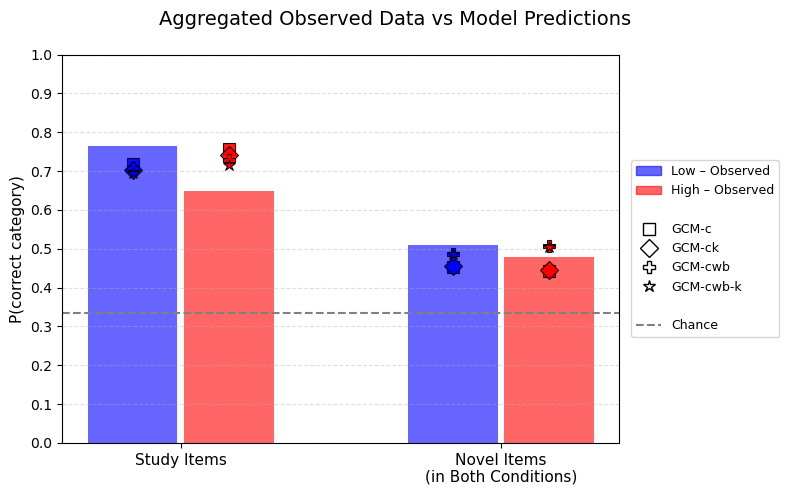

In [ ]:
model_styles_single = {
    'GCM_c':     {'marker': 's', 'label': 'GCM-c'},
    'GCM_ck':    {'marker': 'D', 'label': 'GCM-ck'},
    'GCM_cwb':   {'marker': 'P', 'label': 'GCM-cwb'},
    'GCM_cwb_k': {'marker': '*', 'label': 'GCM-cwb-k'},
}

plot_agg_obs_vs_pred(all_predictions, filtered_data_test, model_styles_single)#,
                 #save_path='plots/model_preds/aggregated_preds.png')

## Pred vs Obs

In [ ]:
# def plot_calibration(model_name, models_fits, filtered_data_test,
#                      distances_dict, image_info):

#     entry    = models_fits[model_name]
#     model_fn = entry['model_fn']

#     # ── Get predictions ───────────────────────────────────────────────────
#     if not entry['per_condition']:
#         _, result_df = model_fn(entry['fit'].x)
#     else:
#         dfs = []
#         for cond in ['Low', 'High']:
#             fit                 = entry['fit'][cond]
#             data_cond           = filtered_data_test[filtered_data_test['condition'] == cond]
#             distances_dict_cond = {cond: distances_dict[cond]}
#             _, res              = model_fn(fit.x, data_test=data_cond,
#                                            distances_dict=distances_dict_cond,
#                                            image_info=image_info)
#             dfs.append(res)
#         result_df = pd.concat(dfs, ignore_index=True)

#     result_df = result_df.merge(
#         filtered_data_test[['subject_id', 'condition', 'image_id',
#                              'category', 'response']],
#         on=['subject_id', 'condition', 'image_id'], how='left'
#     )

#     # ── Aggregate per (condition, image_id, true_category, response_category)
#     agg_records = []
#     for (cond, image_id, true_cat), grp in result_df.groupby(['condition', 'image_id', 'category']):
#         n_total = len(grp)
#         for resp_cat in [1, 2, 3]:
#             pred_prob = grp[f'cat_{resp_cat}_pred_prob'].mean()
#             obs_prop  = (grp['response'] == resp_cat).sum() / n_total
#             agg_records.append({
#                 'condition': cond,
#                 'image_id':  image_id,
#                 'true_cat':  true_cat,
#                 'resp_cat':  resp_cat,
#                 'pred_prob': pred_prob,
#                 'obs_prop':  obs_prop,
#             })
#     agg_df = pd.DataFrame(agg_records)

#     # ── Plot styles ───────────────────────────────────────────────────────
#     cat_colors   = {1: 'orange', 2: 'green', 3: 'purple'}
#     resp_markers = {1: 'o',   2: 's',     3: '^'}
#     cat_labels   = {1: 'Category 1', 2: 'Category 2', 3: 'Category 3'}

#     fig, axes = plt.subplots(3, 2, figsize=(12, 14),
#                              sharey=True, sharex=True)

#     for row, true_cat in enumerate([1, 2, 3]):
#         color = cat_colors[true_cat]

#         for col, cond in enumerate(['Low', 'High']):
#             ax     = axes[row, col]
#             subset = agg_df[(agg_df['condition'] == cond) &
#                             (agg_df['true_cat']  == true_cat)]

#             for resp_cat in [1, 2, 3]:
#                 cell       = subset[subset['resp_cat'] == resp_cat]
#                 marker     = resp_markers[resp_cat]
#                 is_correct = (true_cat == resp_cat)

#                 ax.scatter(
#                     cell['pred_prob'], cell['obs_prop'],
#                     marker     = marker,
#                     color      = color if is_correct else 'none',
#                     edgecolors = color,
#                     linewidths = 1.5,
#                     s          = 50,
#                     alpha      = 0.7,
#                     label      = f'Resp={resp_cat}{"  ✓" if is_correct else ""}'
#                 )

#             ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
#             ax.axhline(1/3, color='gray', linestyle='dotted', linewidth=2, alpha=0.8, label = 'Chance level')
#             ax.axvline(1/3, color='gray', linestyle='dotted', linewidth=2, alpha=0.8) # that's also chance but 
#                                                                                       # we don't need both in the legend
#             ax.set_xlim(0, 1)
#             ax.set_ylim(0, 1)
#             ax.grid(alpha=0.3)
#             ax.set_title(f'{cond} — True cat: {cat_labels[true_cat]}',
#                          fontsize=11)
#             ax.legend(fontsize=8, loc='upper left')

#     for ax in axes[-1, :]:
#         ax.set_xlabel('Model predicted probability', fontsize=11)
#     for ax in axes[:, 0]:
#         ax.set_ylabel('Observed proportion', fontsize=11)

#     fig.suptitle(f'Model predictions — {model_name}', fontsize=14)
#     plt.tight_layout()
#     plt.show()

In [ ]:
# model_names_singles = ['GCM_c','GCM_ck','GCM_cwb','GCM_cwb_k']
# for mod in model_names_singles:
#     plot_calibration(mod, 
#                      models_fits, 
#                      filtered_data_test,
#                      distances_dict, 
#                      image_info)

In [ ]:
def plot_calibration(agg_df, model_name, save_path=None,
                     item_types  = ['Study', 'Novel_Both'],
                     item_labels = ['Study', 'Novel (Both)']):

    cond_colors  = {'Low': 'blue', 'High': 'red'}
    resp_markers = {1: 'o', 2: 's', 3: '^'}
    cat_labels   = {1: 'Category 1', 2: 'Category 2', 3: 'Category 3'}

    n_cols = len(item_types)
    n_rows = len(resp_markers)
    fig, axes = plt.subplots(3, n_cols, figsize=(6 * n_cols, 5 * n_rows),
                             sharey=True, sharex=True)

    for row, true_cat in enumerate([1, 2, 3]):
        for col, (item_type, item_label) in enumerate(zip(item_types, item_labels)):
            ax = axes[row, col]

            for cond in ['Low', 'High']:
                cond_color = cond_colors[cond]
                subset = agg_df[(agg_df['condition'] == cond)  &
                                (agg_df['true_cat']  == true_cat) &
                                (agg_df['item_type'] == item_type)]

                for resp_cat in [1, 2, 3]:
                    cell       = subset[subset['resp_cat'] == resp_cat]
                    marker     = resp_markers[resp_cat]
                    is_correct = (true_cat == resp_cat)

                    ax.scatter(
                        cell['pred_prob'], cell['obs_prop'],
                        marker     = marker,
                        color      = cond_color if is_correct else 'none',
                        edgecolors = cond_color,
                        linewidths = 1.5,
                        s          = 50,
                        alpha      = 0.6,
                    )

            ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
            ax.axhline(1/3, color='gray', linestyle='dotted', linewidth=2, alpha=0.8)
            ax.axvline(1/3, color='gray', linestyle='dotted', linewidth=2, alpha=0.8)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.grid(alpha=0.3)
            ax.set_title(f'True: {cat_labels[true_cat]} — {item_label}', fontsize=13)

    for ax in axes[-1, :]:
        ax.set_xlabel('Model predicted probability', fontsize=13)
    for ax in axes[:, 0]:
        ax.set_ylabel('Observed proportion', fontsize=13)

    # ── Shared legend ──────────────────────────────────────────────────────
    separator = mlines.Line2D([], [], linestyle='None', label='')

    legend_elements = []
    for cond in ['Low', 'High']:
        cond_color = cond_colors[cond]
        for resp_cat in [1, 2, 3]:
            marker = resp_markers[resp_cat]
            legend_elements.append(
                mlines.Line2D([], [], marker=marker, color=cond_color,
                              markeredgecolor=cond_color, linestyle='None',
                              markersize=13, label=f'{cond} — Resp={resp_cat} ✓')
            )
            legend_elements.append(
                mlines.Line2D([], [], marker=marker, color='none',
                              markeredgecolor=cond_color, linestyle='None',
                              markersize=13, label=f'{cond} — Resp={resp_cat}')
            )
        legend_elements.append(separator)

    legend_elements += [
        mlines.Line2D([0], [0], color='k',    linestyle='--',     linewidth=2, label='Perfect calibration'),
        mlines.Line2D([0], [0], color='gray', linestyle='dotted', linewidth=2, label='Chance level'),
    ]
    fig.legend(handles=legend_elements, fontsize=13,
               bbox_to_anchor=(1.01, 0.5), loc='center left', ncol=1)

    fig.suptitle(f'Model predictions — {model_name}', fontsize=20)
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')

    plt.show()

Saved: plots/model_preds/GCM_c.png


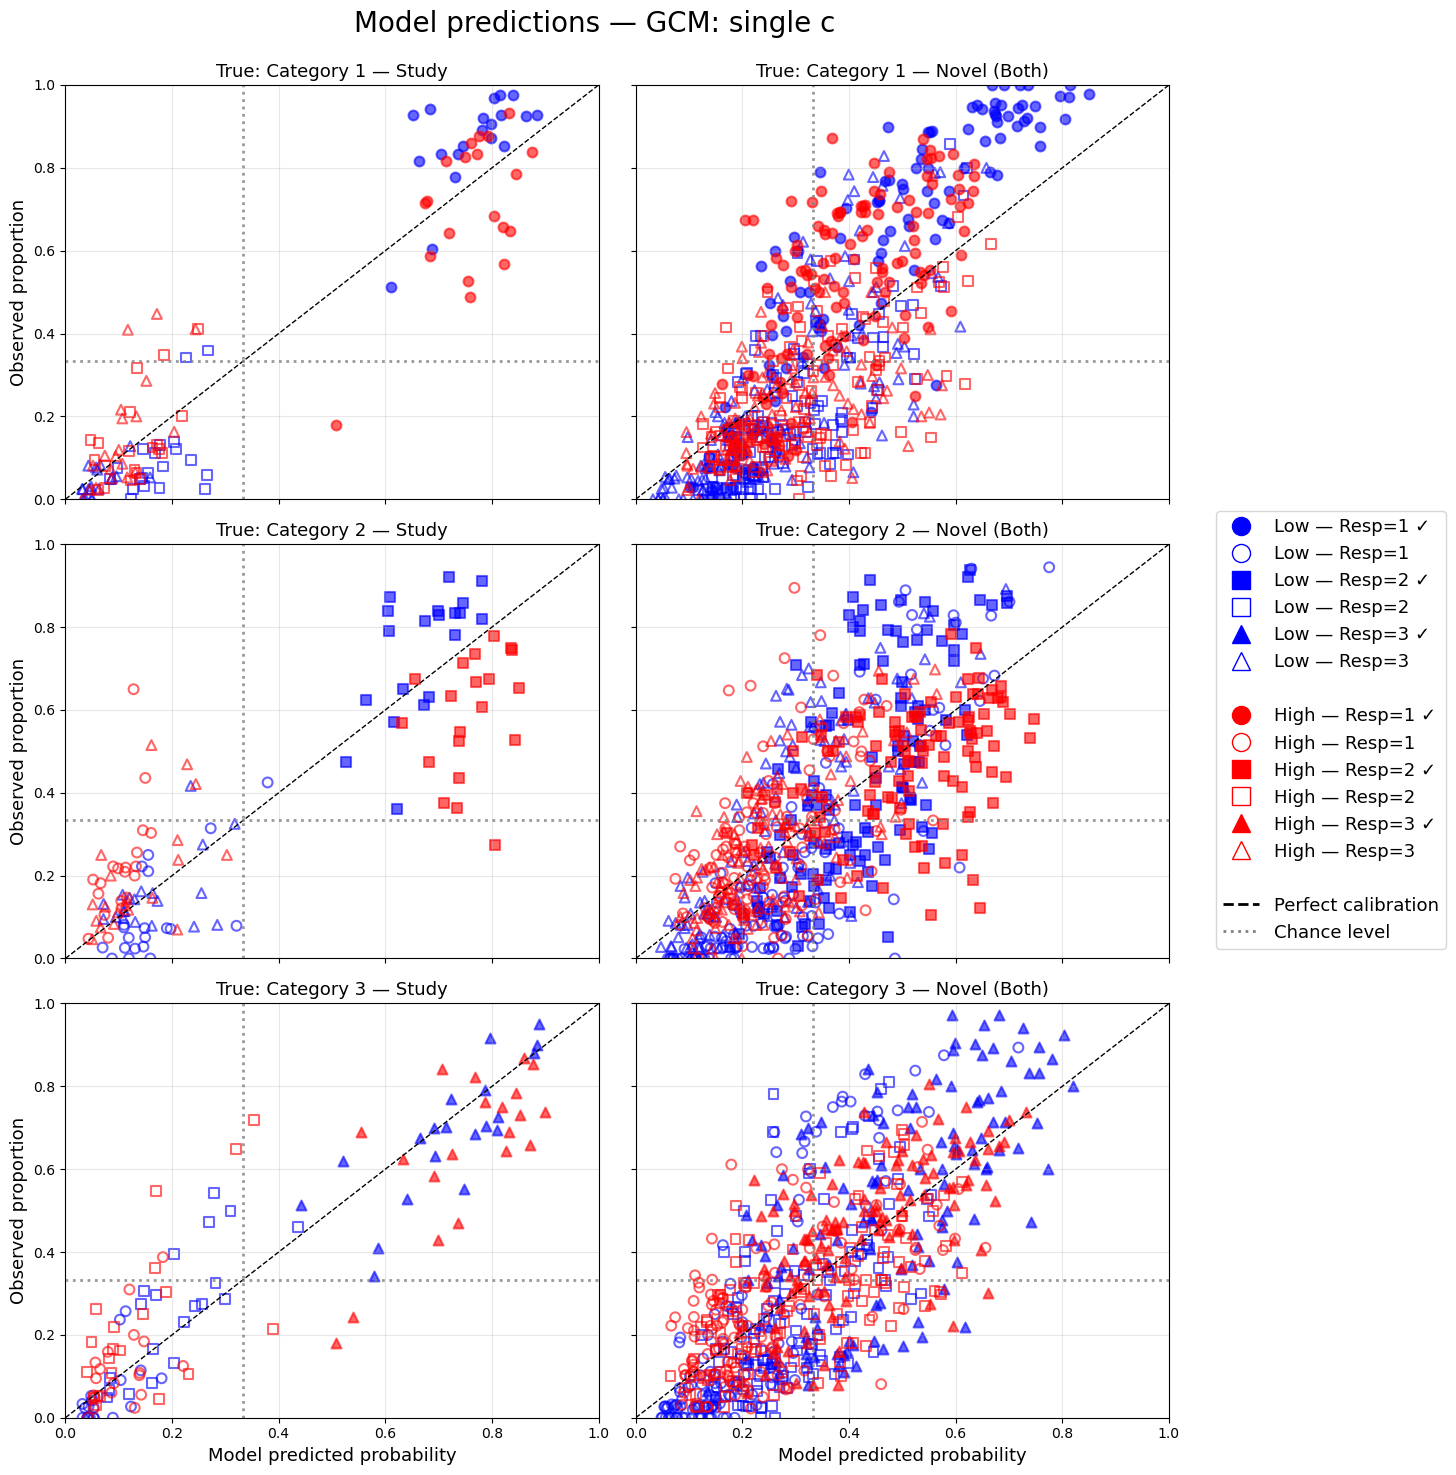

Saved: plots/model_preds/GCM_ck.png


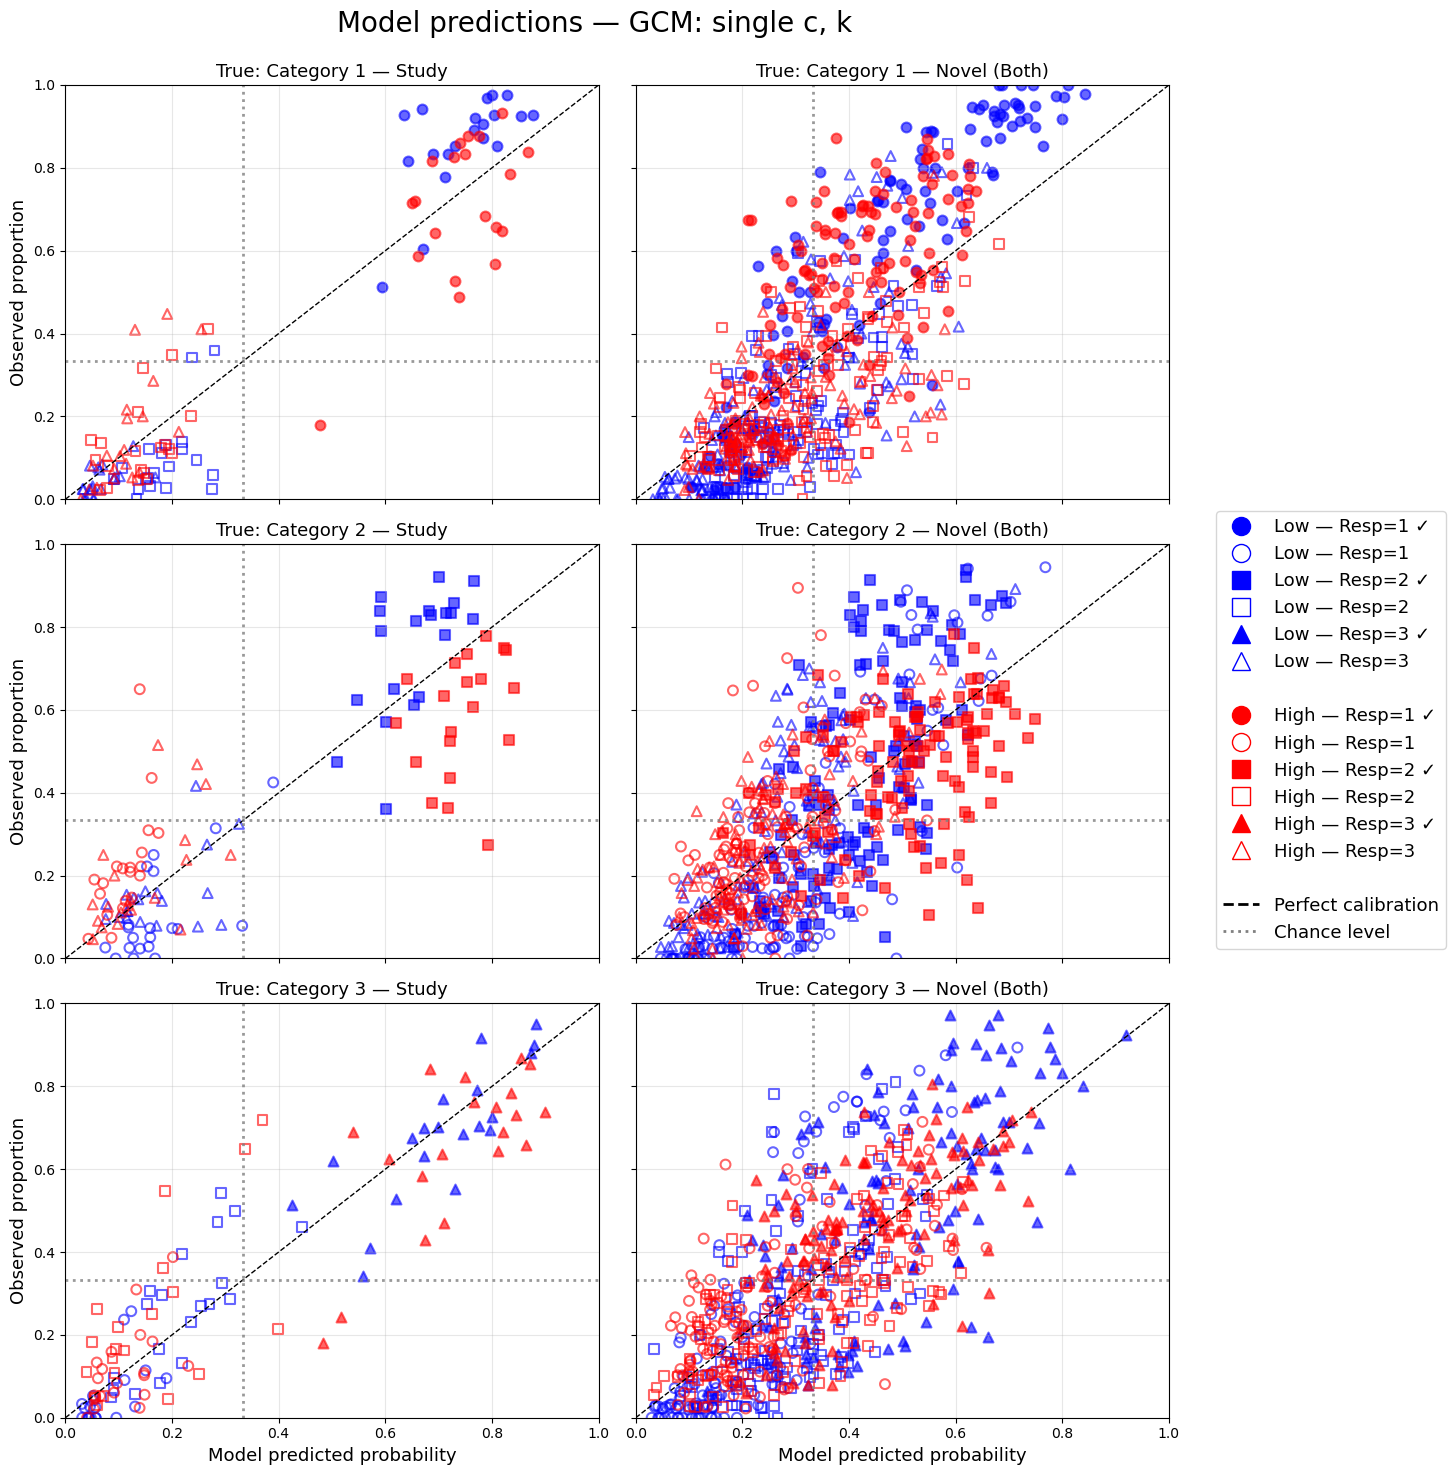

Saved: plots/model_preds/GCM_cwb.png


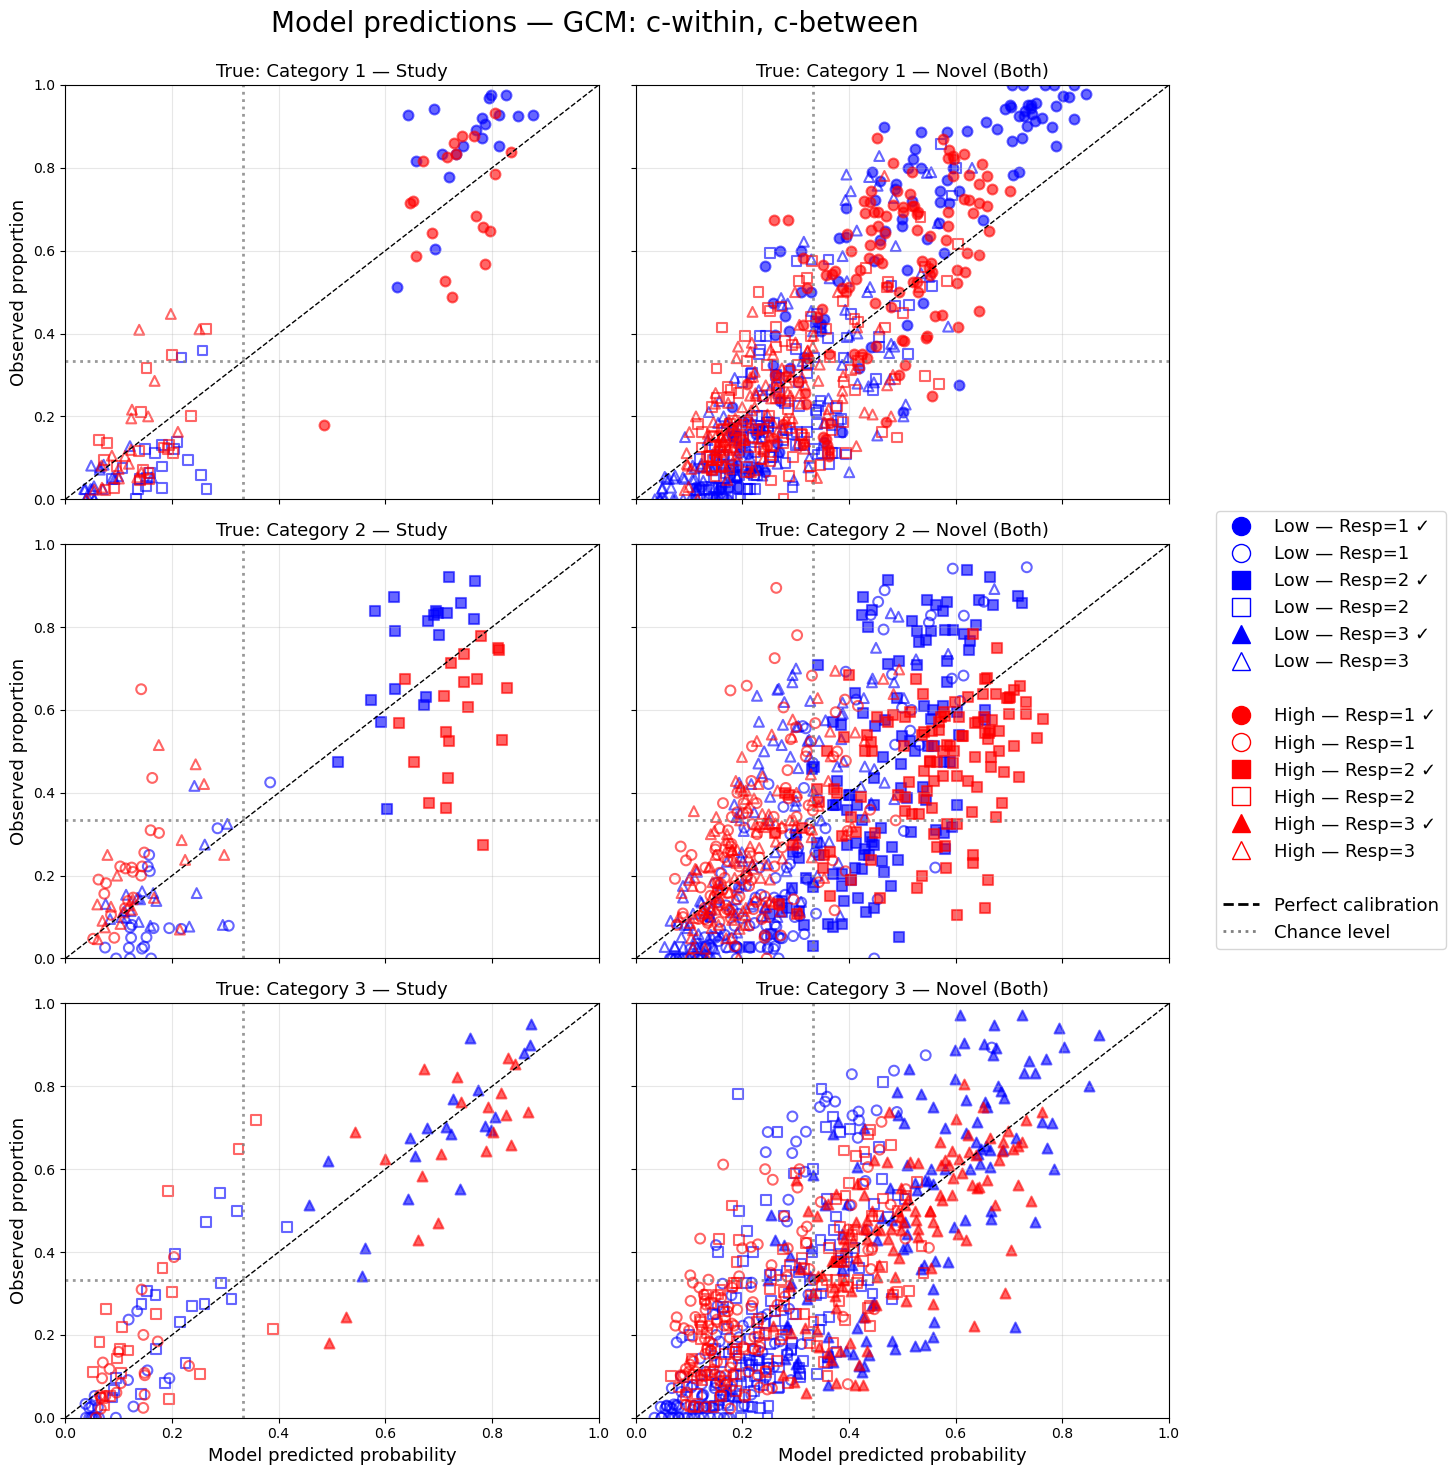

Saved: plots/model_preds/GCM_cwb_k.png


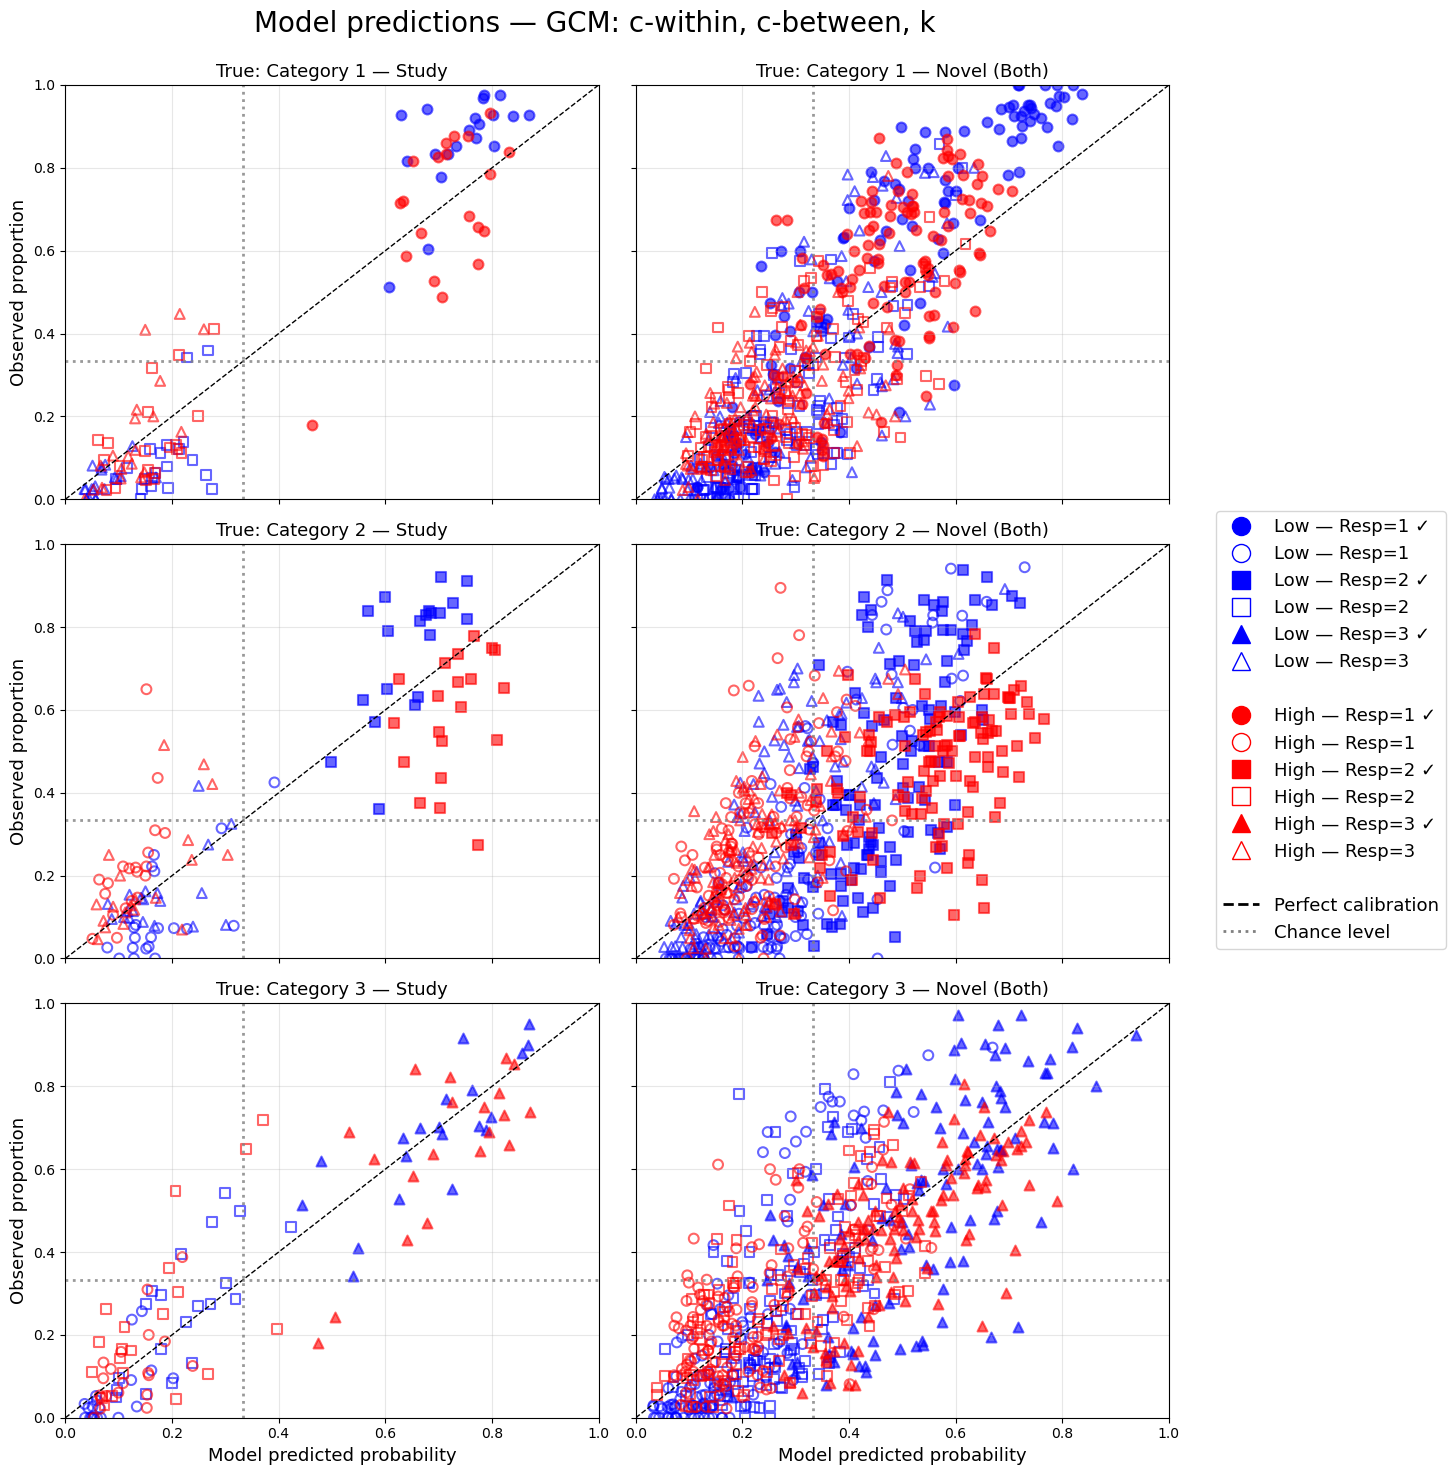

In [ ]:
# Model predictions
model_names_singles = {'GCM_c':'GCM: single c',
                       'GCM_ck':'GCM: single c, k',
                       'GCM_cwb':'GCM: c-within, c-between',
                       'GCM_cwb_k':'GCM: c-within, c-between, k'
                       }
for mod, mod_name in model_names_singles.items():
    #save_path = 'plots/model_preds/' + mod + '.png'
    plot_calibration(all_predictions[mod]['agg_df'], mod_name)

# AIC & BIC

In [ ]:
# Get AIC and BIC
n_obs = len(filtered_data_test)

results = []
for name, entry in models_fits.items():
    if not entry['per_condition']:
        nll      = entry['fit'].fun
        n_params = len(entry['fit'].x)
    else:
        nll      = sum(entry['fit'][c].fun for c in ['Low', 'High'])
        n_params = sum(len(entry['fit'][c].x) for c in ['Low', 'High'])
    aic = 2 * n_params + 2 * nll
    bic = n_params * np.log(n_obs) + 2 * nll
    results.append({'Model': name, 'n_params': n_params,
                    'NLL': nll, 'AIC': aic, 'BIC': bic})

aic_bic_df = pd.DataFrame(results)

In [ ]:
# all models
best_aic = aic_bic_df['AIC'].idxmin()
best_bic = aic_bic_df['BIC'].idxmin()

print(f"{'Model':<25} {'n_params':>10} {'NLL':>12} {'AIC':>12} {'BIC':>12}")
print("-" * 75)
for i, row in aic_bic_df.iterrows():
    aic_marker = ' *' if i == best_aic else '  '
    bic_marker = ' *' if i == best_bic else '  '
    print(f"{row['Model']:<25} {int(row['n_params']):>10} {row['NLL']:>12.2f} "
          f"{row['AIC']:>12.2f}{aic_marker} {row['BIC']:>12.2f}{bic_marker}")

print("\n* = best model for that metric")

Model                       n_params          NLL          AIC          BIC
---------------------------------------------------------------------------
GCM_c                              1     34471.77     68945.54       68954.07  
GCM_c_per_cond                     2     34062.30     68128.60       68145.65  
GCM_ck                             2     34431.55     68867.10       68884.15  
GCM_ck_per_cond                    4     34038.19     68084.37       68118.47  
GCM_cwb                            2     34235.79     68475.58       68492.63  
GCM_cwb_per_cond                   4     33824.37     67656.74       67690.84  
GCM_cwb_k                          3     34212.52     68431.03       68456.60  
GCM_cwb_k_per_cond                 6     33811.54     67635.09 *     67686.23 *

* = best model for that metric


In [ ]:
# only single parameters across conditions models
single_aic_bic_df = aic_bic_df[~aic_bic_df.Model.str.endswith('cond')]

best_aic = single_aic_bic_df['AIC'].idxmin()
best_bic = single_aic_bic_df['BIC'].idxmin()

print(f"{'Model':<25} {'n_params':>10} {'NLL':>12} {'AIC':>12} {'BIC':>12}")
print("-" * 75)
for i, row in single_aic_bic_df.iterrows():
    aic_marker = ' *' if i == best_aic else '  '
    bic_marker = ' *' if i == best_bic else '  '
    print(f"{row['Model']:<25} {int(row['n_params']):>10} {row['NLL']:>12.2f} "
          f"{row['AIC']:>12.2f}{aic_marker} {row['BIC']:>12.2f}{bic_marker}")

print("\n* = best model for that metric")

Model                       n_params          NLL          AIC          BIC
---------------------------------------------------------------------------
GCM_c                              1     34471.77     68945.54       68954.07  
GCM_ck                             2     34431.55     68867.10       68884.15  
GCM_cwb                            2     34235.79     68475.58       68492.63  
GCM_cwb_k                          3     34212.52     68431.03 *     68456.60 *

* = best model for that metric


# MDS Space

## Centroids

In [55]:
# ── Centroids ─────────────────────────────────────────────────────────────
centroids = {}
for cond in ['Low', 'High']:
    centroids[cond] = {}
    for cat in [1, 2, 3]:
        items = study_items_dict[cond][cat]
        centroids[cond][cat] = mds_coords.loc[items].mean(axis=0)  # shape: (8,)

In [56]:
# ── Distances between centroids within each condition ──────────────────────
print(f"{'Condition':<10} {'Cat pair':>10} {'Distance':>12}")
print("-" * 35)

centroid_distances = {}
for cond in ['Low', 'High']:
    centroid_distances[cond] = {}
    for cat_a, cat_b in combinations([1, 2, 3], 2):
        dist = np.linalg.norm(centroids[cond][cat_a].values - 
                              centroids[cond][cat_b].values)
        centroid_distances[cond][(cat_a, cat_b)] = dist
        print(f"{cond:<10} {f'{cat_a} vs {cat_b}':>10} {dist:>12.4f}")
    print()

Condition    Cat pair     Distance
-----------------------------------
Low            1 vs 2       3.1445
Low            1 vs 3       4.8135
Low            2 vs 3       3.1158

High           1 vs 2       2.4678
High           1 vs 3       2.5269
High           2 vs 3       3.0161



In [57]:
# ── Also show as a 3x3 distance matrix per condition ──────────────────────
for cond in ['Low', 'High']:
    print(f"\n{cond} variability — centroid distance matrix:")
    mat = pd.DataFrame(index=[1,2,3], columns=[1,2,3], dtype=float)
    for cat_a in [1, 2, 3]:
        for cat_b in [1, 2, 3]:
            if cat_a == cat_b:
                mat.loc[cat_a, cat_b] = 0.0
            elif cat_a < cat_b:
                mat.loc[cat_a, cat_b] = centroid_distances[cond][(cat_a, cat_b)]
            else:
                mat.loc[cat_a, cat_b] = centroid_distances[cond][(cat_b, cat_a)]
    print(mat.to_string())


Low variability — centroid distance matrix:
          1         2         3
1  0.000000  3.144460  4.813497
2  3.144460  0.000000  3.115764
3  4.813497  3.115764  0.000000

High variability — centroid distance matrix:
          1         2         3
1  0.000000  2.467765  2.526865
2  2.467765  0.000000  3.016130
3  2.526865  3.016130  0.000000


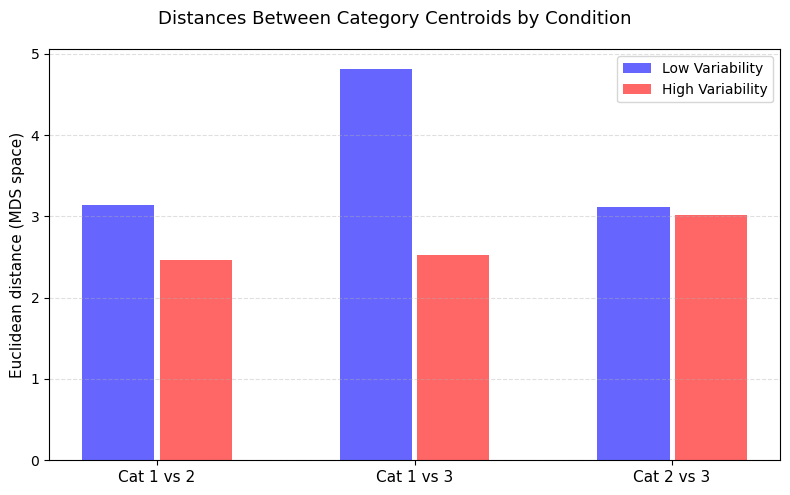

In [58]:
# Visualization
pair_labels = ['Cat 1 vs 2', 'Cat 1 vs 3', 'Cat 2 vs 3']
pairs       = [(1, 2), (1, 3), (2, 3)]

fig, ax = plt.subplots(figsize=(8, 5))

conditions   = ['Low', 'High']
colors_cond  = {'Low': 'blue', 'High': 'red'}
offset       = {'Low': -0.15, 'High': 0.15}
x            = np.arange(len(pairs))

for cond in conditions:
    heights = [centroid_distances[cond][pair] for pair in pairs]
    ax.bar(x + offset[cond], heights, width=0.28,
           color=colors_cond[cond], alpha=0.6, label=f'{cond} Variability')

ax.set_xticks(x)
ax.set_xticklabels(pair_labels, fontsize=11)
ax.set_ylabel('Euclidean distance (MDS space)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Distances Between Category Centroids by Condition', fontsize=13)
plt.tight_layout()
plt.show()

## 2D Category visualizations

In [62]:
# ── Gather all study items and their MDS coords ───────────────────────────
study_records = []
for cond in ['Low', 'High']:
    for cat in [1, 2, 3]:
        items = study_items_dict[cond][cat]
        coords = mds_coords.loc[items]
        for image_id, row in coords.iterrows():
            study_records.append({
                'image_id':  image_id,
                'condition': cond,
                'category':  cat,
                'coords':    row.values
            })

study_df = pd.DataFrame(study_records)


In [63]:

# ── PCA: reduce 8D → 2D ───────────────────────────────────────────────────
all_coords = np.stack(study_df['coords'].values)
pca        = PCA(n_components=2)
coords_2d  = pca.fit_transform(all_coords)

study_df['PC1'] = coords_2d[:, 0]
study_df['PC2'] = coords_2d[:, 1]

var_explained = pca.explained_variance_ratio_ * 100


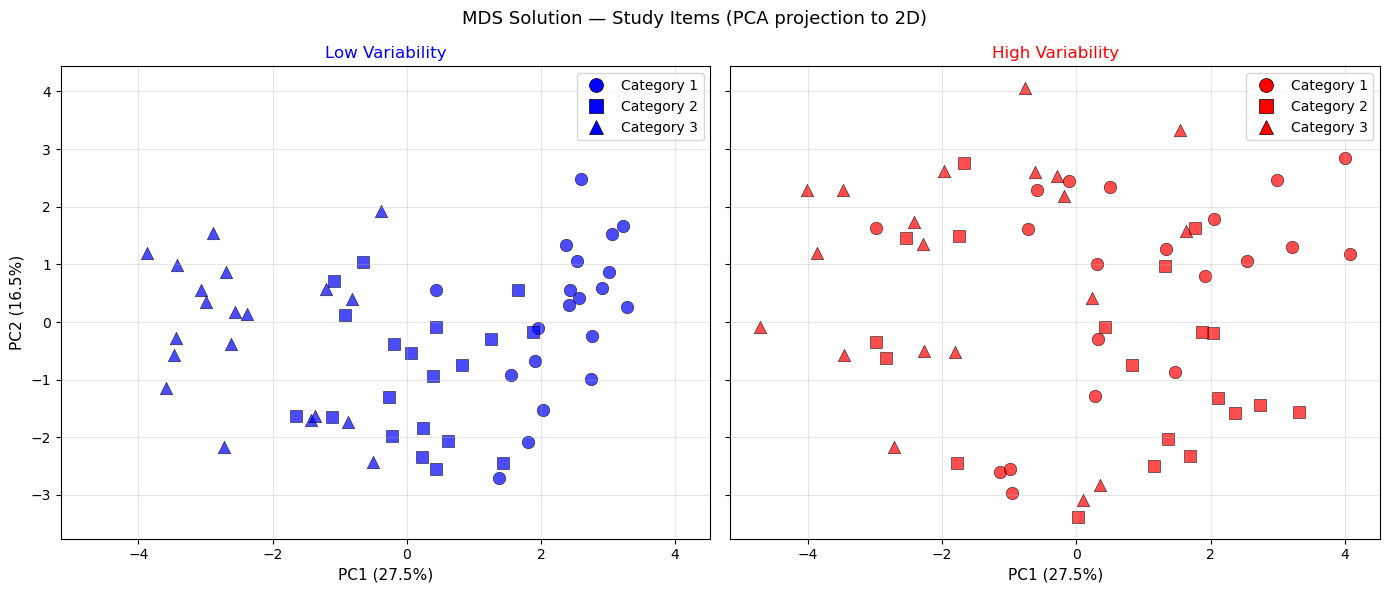

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, cond in zip(axes, ['Low', 'High']):
    for cat in [1, 2, 3]:
        subset = study_df[(study_df['condition'] == cond) &
                          (study_df['category']  == cat)]
        ax.scatter(
            subset['PC1'], subset['PC2'],
            color      = cond_colors[cond],
            marker     = cat_markers[cat],
            s          = 80,
            alpha      = 0.7,
            edgecolors = 'black',
            linewidths = 0.5,
        )

    ax.set_title(f'{cond} Variability', fontsize=12, color=cond_colors[cond])
    ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}%)', fontsize=11)
    ax.grid(alpha=0.3)

    # Legend per subplot
    legend_elements = [
        mlines.Line2D([], [], marker=cat_markers[cat],
                      color=cond_colors[cond],
                      markeredgecolor='black', markeredgewidth=0.5,
                      linestyle='None', markersize=10,
                      label=cat_labels[cat])
        for cat in [1, 2, 3]
    ]
    ax.legend(handles=legend_elements, fontsize=10, loc='best')

axes[0].set_ylabel(f'PC2 ({var_explained[1]:.1f}%)', fontsize=11)

plt.suptitle('MDS Solution — Study Items (PCA projection to 2D)', fontsize=13)
plt.tight_layout()
plt.show()

# Save results

In [ ]:
# Save
with open('GCM_results.pkl', 'wb') as f:
    pickle.dump({
        'models_fits':      models_fits,
        'all_predictions':  all_predictions,
        'image_info':       image_info,
        'distances_dict':   distances_dict,
    }, f)
print('Saved GCM_results.pkl')

Saved GCM_results.pkl
